# 12 · Dengesiz Veri Öğrenimi (Imbalanced Learning)

**Classical-ML-lab / 04_model_evaluation_improvement**

> **Bu notebook'ta ne öğreneceğiz?**
> Sınıflardan birinin diğerine göre çok az örnekle temsil edildiği (dolandırıcılık, nadir hastalık,
> ekipman arızası gibi) veri setlerinde standart öğrenme algoritmalarının neden başarısız olduğunu,
> ve bunu düzeltmek için kullanılan tüm ana aile teknikleri —  rastgele/akıllı yeniden örnekleme
> (oversampling/undersampling), SMOTE ailesi, sınıf ağırlıklandırma, maliyet-duyarlı öğrenme, karar
> eşiği taşıma ve dengesizliğe duyarlı ensemble yöntemleri — uçtan uca, gerçek veri setleri üzerinde
> işleyeceğiz. En kritik metodolojik tuzağı da (yeniden örneklemeyi çapraz doğrulamanın YANLIŞ
> yerinde yapmak, yani veri sızıntısı) somut sayılarla göstereceğiz.
>
> **Önkoşul:** [[11_model_evaluation_metrics]] — precision/recall/F1, ROC/PR eğrileri, kalibrasyon.
> Bu notebook o metrikleri artık *ölçmekle* değil, dengesizliği *düzeltmekle* ilgileniyor.
>
> **Veri:** Credit Card Fraud Detection (Kaggle/ULB — Pozzolo et al. 2015), Oil Spill (Kubat, Holte
> & Matwin 1998, UCI), Mammography (Woods et al. 1993, UCI) — üçü de dengesiz veri öğreniminin
> literatüründeki klasik referans veri setleri.
>
> **Araçlar:** Python (`imbalanced-learn`, `scikit-learn`, `xgboost`, `lightgbm`), R (`ROSE`,
> `smotefamily`, `unbalanced`, `randomForest`, `ebmc`, `caret`, `pROC`), SQL (DuckDB).


## 1 · Dengesiz Veri Problemi ve "Doğruluk Paradoksu"

**Sınıf dengesizliği (class imbalance)**, bir sınıflandırma probleminde hedef sınıflardan birinin
(**çoğunluk / majority**) diğerine (**azınlık / minority**) göre çok daha fazla örnekle temsil
edildiği durumdur. Dengesizlik oranı (Imbalance Ratio, IR) genelde $IR = N_{maj}/N_{min}$ olarak
tanımlanır. IR birkaç kata kadar "hafif dengesizlik" sayılırken, 1:100 ve ötesi (bu notebook'ta
göreceğimiz Kredi Kartı Dolandırıcılığı veri setinde **1:578**) "aşırı dengesizlik" (extreme
imbalance) olarak adlandırılır.

**Neden standart algoritmalar başarısız olur?** Çoğu öğrenme algoritması (lojistik regresyon,
karar ağaçları, SVM...) toplam hatayı (ya da olabilirliği) minimize etmeye çalışır. %99.8'i
çoğunluk sınıfından oluşan bir veri setinde, **her şeyi çoğunluk sınıfı olarak tahmin eden** bir
model bile %99.8 doğruluk (accuracy) elde eder — ama azınlık sınıfını (asıl önemsediğimiz sınıfı!)
hiç yakalayamaz. Buna **doğruluk paradoksu (accuracy paradox)** denir; [[11_model_evaluation_metrics]]
notebook'unda bu yüzden precision/recall/F1/PR-AUC'nin accuracy'den neden daha güvenilir olduğunu
görmüştük — burada bu metrikleri *iyileştirmek* için somut teknikler uygulayacağız.

**Endüstride nerede karşımıza çıkar?**
- **Finans:** Kredi kartı dolandırıcılığı tespiti (işlemlerin ~%0.1-0.2'si dolandırıcılık), kredi
  temerrüdü tahmini, kara para aklama (AML) tespiti.
- **Sağlık:** Nadir hastalık taraması (örn. kanser taramasında pozitif vaka oranı çok düşüktür),
  yoğun bakımda mortalite tahmini, ilaç yan etkisi tespiti.
- **Savunma ve güvenlik:** Radar/uydu görüntülerinde nadir tehdit tespiti (bu notebook'ta
  kullanacağımız Oil Spill veri seti tam olarak bu kategoriden — uydu radar görüntülerinde petrol
  sızıntısı tespiti), ağ güvenliğinde saldırı/izinsiz giriş tespiti (intrusion detection — trafiğin
  büyük çoğunluğu normaldir), sınır güvenliğinde anomali tespiti.
- **Enerji ve üretim:** Ekipman arızası / kestirimci bakım (arıza olayları nadirdir ama maliyeti
  çok yüksektir), enerji şebekesinde anomali/kaçak tespiti, kalite kontrolde nadir kusurlu ürün
  tespiti.
- **Pazarlama/Churn:** Müşteri kaybı (churn) tahmini, reklam tıklama oranı (CTR) tahmini.

Bu örneklerin ortak noktası: **azınlık sınıfını kaçırmanın maliyeti, çoğunluk sınıfını yanlış
alarma çevirmenin maliyetinden çok daha yüksektir** (bir dolandırıcılık işlemini kaçırmak, meşru
bir işlemi incelemeye almaktan çok daha pahalıdır). Bu notebook'taki tüm teknikler, modelleri bu
asimetriye duyarlı hale getirmeyi hedefler.


## 2 · Çözüm Ailelerinin Taksonomisi

Dengesiz veriyle başa çıkmak için dört ana strateji ailesi vardır:

| Aile | Fikir | Ne zaman uygun? |
|---|---|---|
| **Veri seviyesi — Yeniden örnekleme** | Eğitim verisinin kendisini dengeye getir (oversampling/undersampling/hibrit) | Algoritmadan bağımsız çalışır, herhangi bir modelle kullanılabilir |
| **Algoritma seviyesi — Sınıf ağırlıklandırma / Maliyet-duyarlılık** | Kayıp fonksiyonunda azınlık sınıfının hatasına daha fazla ceza ver | Veriyi değiştirmeden, modelin optimizasyon hedefini değiştirir |
| **Karar seviyesi — Eşik taşıma** | Modeli değiştirmeden, `predict_proba` çıktısını yorumlama eşiğini kaydır | En ucuz müdahale; herhangi bir olasılık-çıktılı modelle çalışır |
| **Ensemble seviyesi** | Birden fazla dengeli alt-örneklem/alt-model üretip birleştir | Undersampling'in bilgi kaybını, çoklu alt-örneklemle telafi eder |

Bu dört aile **birbirini dışlamaz** — pratikte genelde birkaçı birlikte kullanılır (örn. SMOTE +
sınıf ağırlıklandırma + eşik taşıma). Bu notebook'ta hepsini sırayla, gerçek veri setleri üzerinde
göreceğiz.

**Oversampling vs. Undersampling — temel ödünleşim:**
- **Oversampling** (azınlığı çoğaltma): Hiçbir bilgi kaybetmez (çoğunluk sınıfı olduğu gibi kalır)
  ama azınlık sınıfında **aşırı öğrenmeye (overfitting)** yol açabilir — özellikle rastgele
  kopyalama (Random Oversampling) durumunda model, aynı örnekleri defalarca görüp onları ezberler.
- **Undersampling** (çoğunluğu azaltma): Aşırı öğrenme riski daha düşüktür ama çoğunluk sınıfından
  **potansiyel olarak değerli bilgi kaybedilir** — özellikle çoğunluk sınıfı zaten az sayıda
  örnekle temsil ediliyorsa (örn. Oil Spill'de sadece 896 çoğunluk örneği var) bu kayıp ciddi
  olabilir.

Bu ödünleşim yüzünden literatür, rastgele değil **"akıllı" (informed)** yeniden örnekleme
tekniklerine yönelmiştir — hangi örneklerin sentezleneceğine veya silineceğine karar verirken
sınıflar arası sınırı (decision boundary) dikkate alan yöntemler (SMOTE ailesi, Tomek Links, ENN
gibi). Bunları sırayla işleyeceğiz.


## 3 · Rastgele Yeniden Örnekleme (Random Over/Undersampling)

En basit ve en hızlı yöntemler:

- **Random Oversampling (RO):** Azınlık sınıfından örnekler **rastgele, yerine koyarak (with
  replacement)** tekrar tekrar seçilip veri setine eklenir, ta ki iki sınıf dengelenene kadar
  (ya da hedeflenen bir orana ulaşana kadar). Yeni bilgi üretmez — sadece var olan örnekleri
  çoğaltır.
- **Random Undersampling (RU):** Çoğunluk sınıfından örnekler **rastgele silinir**, ta ki iki sınıf
  dengelenene kadar. Basit ama çoğunluk sınıfının sınır bölgesindeki (decision boundary'ye yakın,
  bilgi açısından değerli) örnekleri de rastgele silme riski taşır.

**Endüstride nerede kullanılır?** Hızlı bir temel çizgi (baseline) kurmak için — örn. bir kredi
riski modelleme ekibi, daha karmaşık SMOTE varyantlarına geçmeden önce RO/RU ile hızlı bir
prototip çalıştırıp iyileşme potansiyelinin büyüklüğünü ölçer. Çok büyük veri setlerinde (milyonlarca
satır, örn. reklam tıklama tahmini) RU, hesaplama maliyetini düşürmek için de tercih edilir —
çoğunluk sınıfını küçültmek eğitim süresini kısaltır.


## 4 · SMOTE Ailesi — Sentetik Azınlık Örneği Üretimi

**SMOTE (Synthetic Minority Over-sampling Technique, Chawla et al. 2002)** rastgele kopyalamanın
aşırı öğrenme sorununu çözmek için **var olan azınlık örnekleri arasında enterpolasyon yaparak yeni,
sentetik** örnekler üretir:

$$x_{new} = x_i + \lambda \cdot (x_{zi} - x_i), \quad \lambda \sim U(0, 1)$$

Burada $x_i$ azınlık sınıfından rastgele seçilen bir örnek, $x_{zi}$ onun $k$ en yakın komşusundan
(yine azınlık sınıfından) rastgele seçilen biri, $\lambda$ ise $[0,1]$ aralığında rastgele bir
katsayıdır. Sonuç: iki gerçek örneğin arasındaki doğru üzerinde yeni bir nokta — özellik uzayında
azınlık sınıfının "yoğunluğunu" artıran ama tam kopya olmayan bir örnek.

**SMOTE'un sorunu ve varyantları:** SMOTE, azınlık sınıfının TÜM örnekleri arasında ayrım
gözetmeden enterpolasyon yapar — bu da bazen çoğunluk sınıfı bölgesinin içine "sızan" gürültülü
sentetik örnekler üretebilir. Bunu düzeltmek için:

- **Borderline-SMOTE (Han, Wang & Mao 2005):** Sadece **sınır bölgesindeki** azınlık örnekleri
  (yani komşularının çoğu çoğunluk sınıfından olan, "riskli" örnekler) etrafında sentetik örnek
  üretir — çünkü karar sınırına yakın örnekler sınıflandırma için daha bilgilendiricidir.
- **ADASYN (Adaptive Synthetic Sampling, He et al. 2008):** Her azınlık örneği için, o örneğin
  ne kadar "zor" olduğuna (komşularının ne kadarının çoğunluk sınıfından olduğuna) bağlı olarak
  **adaptif olarak farklı sayıda** sentetik örnek üretir — zor örnekler etrafında daha yoğun,
  kolay örnekler etrafında daha seyrek.
- **SMOTENC / SMOTEN:** Klasik SMOTE sadece sayısal özniteliklerde enterpolasyon yapabilir.
  **SMOTENC** kategorik+sayısal karışık veri için (kategorik öznitelikte enterpolasyon yerine en
  sık görülen değeri atar), **SMOTEN** ise tamamen kategorik veri için tasarlanmıştır.

**Endüstride nerede kullanılır?** Tıbbi görüntülemede nadir hastalık sınıfı için sentetik örnek
üretimi (etiketli gerçek veri toplamak pahalı/yavaş olduğunda), kredi skorlama modellerinde
temerrüt sınıfını zenginleştirme, endüstriyel kalite kontrolde nadir kusur türlerinin sentetik
çoğaltılması — SMOTE, 2002'den beri en çok atıf alan makine öğrenmesi makalelerinden biridir ve
`imbalanced-learn`, `smotefamily` (R) gibi neredeyse her kütüphanede standart olarak bulunur.


## 5 · Akıllı Undersampling Ailesi

Rastgele undersampling'in bilgi kaybı sorununu azaltmak için, **hangi çoğunluk örneklerinin
silineceğine karar sınırına göre karar veren** yöntemler geliştirilmiştir:

- **Tomek Links (Tomek 1976):** İki örnek $(x_i, x_j)$ farklı sınıflardansa ve aralarında başka
  hiçbir örnek yoksa (yani birbirlerinin en yakın komşusuysa), bu çifte **Tomek bağlantısı**
  denir. Böyle bir çiftteki **çoğunluk sınıfı örneği silinir** — bu, sınıflar arası "gürültülü"
  veya çakışan (overlapping) bölgeyi temizler ve karar sınırını netleştirir. Genelde SMOTE
  sonrası bir **temizleme adımı** olarak da kullanılır.
- **Edited Nearest Neighbours (ENN, Wilson 1972):** Her örnek için $k$ en yakın komşusuna bakılır;
  eğer bir örneğin komşularının çoğunluğu kendi sınıfından **değilse**, o örnek silinir. Tomek'ten
  daha agresif temizleme yapar (birden fazla komşuya bakar).
- **NearMiss (Mani & Zhang 2003):** Çoğunluk örnekleri, azınlık sınıfına olan **mesafeye göre**
  seçilir. Üç versiyonu vardır: **NearMiss-1** azınlığa en yakın $k$ komşunun ortalama mesafesi en
  küçük olan çoğunluk örneklerini tutar (sınır bölgesine odaklanır), **NearMiss-2** azınlığa en
  UZAK $k$ komşunun ortalama mesafesi en küçük olanları tutar, **NearMiss-3** her azınlık örneği
  için önce en yakın birkaç çoğunluk komşusunu bulup sonra bunlardan en uzak olanları seçer (daha
  dengeli bir kapsama sağlar).
- **Cluster Centroids:** Çoğunluk sınıfı $K$-Means ile kümelenir ve her kümenin **merkezî (centroid)**
  noktası, o kümedeki tüm örnekleri temsilen veri setinde tutulur — bilgi kaybını azaltmaya çalışan
  bir özet/sıkıştırma yaklaşımı.

**Endüstride nerede kullanılır?** Ağ güvenliği (intrusion detection) sistemlerinde normal trafiğin
milyonlarca kaydı arasından sınıflandırma için en bilgilendirici alt-küme seçilirken (hem
hesaplama maliyetini düşürmek hem sınır netliğini artırmak için) Tomek Links/ENN yaygın kullanılır;
tıbbi teşhis modellerinde sağlıklı-hasta sınırındaki "belirsiz" vakaları temizlemek için de
kullanılır.


## 6 · Hibrit (Kombine) Yöntemler

SMOTE'un ürettiği sentetik örnekler bazen çoğunluk sınıfı bölgesine "taşabilir" (özellikle sınıflar
örtüşüyorsa). Bunu düzeltmek için, **önce oversampling sonra temizleme (cleaning undersampling)**
yapan hibrit yöntemler geliştirilmiştir:

- **SMOTEENN (Batista, Bazzan & Monard 2004):** Önce SMOTE ile azınlık sınıfı zenginleştirilir,
  sonra **ENN** ile hem çoğunluk hem azınlık sınıfından "gürültülü"/çakışan örnekler temizlenir.
- **SMOTETomek (Batista, Prati & Monard 2004):** Önce SMOTE, sonra **Tomek Links** ile temizleme
  yapılır. ENN'e göre daha az agresif temizler (sadece karşılıklı en-yakın-komşu çiftlerini siler).

Batista ve arkadaşlarının 2004 tarihli karşılaştırmalı çalışması, yüksek dengesizlik oranına sahip
ve sınıfları örtüşen veri setlerinde bu hibrit yöntemlerin saf SMOTE'dan genelde daha iyi
performans gösterdiğini bulmuştur — çünkü SMOTE'un "kirlettiği" bölgeyi ENN/Tomek geri temizler.

**Endüstride nerede kullanılır?** Kredi kartı dolandırıcılığı ve sağlık sigortası dolandırıcılığı
tespiti gibi, sınıfların özellik uzayında ciddi örtüştüğü (yani dolandırıcı işlemlerin bazılarının
meşru işlemlere çok benzediği) problemlerde SMOTEENN/SMOTETomek saf SMOTE'a tercih edilir.


## 7 · Sınıf Ağırlıklandırma ve Maliyet-Duyarlı Öğrenme

Veri seviyesinde hiçbir şeyi değiştirmeden, **algoritmanın optimize ettiği kayıp fonksiyonunu**
değiştirmek de mümkündür: azınlık sınıfının her bir hatasına, çoğunluk sınıfının hatasından daha
büyük bir ceza (ağırlık) verilir.

- **`class_weight='balanced'` (scikit-learn):** Ağırlıklar otomatik olarak
  $w_c = \dfrac{N}{K \cdot N_c}$ formülüyle hesaplanır ($N$: toplam örnek, $K$: sınıf sayısı,
  $N_c$: $c$ sınıfındaki örnek sayısı) — az örnekli sınıfa otomatik olarak daha yüksek ağırlık
  verilir. `LogisticRegression`, `SVC`, `RandomForestClassifier`, `DecisionTreeClassifier` gibi
  neredeyse tüm scikit-learn sınıflandırıcılarında mevcuttur. Elle bir sözlük de verilebilir
  (örn. `{0: 1, 1: 25}`) — bu, iş bilgisine dayalı bir **maliyet matrisini** doğrudan modele
  kodlamanın bir yoludur (örn. bir dolandırıcılığı kaçırmanın maliyeti, meşru bir işlemi
  incelemeye almaktan 25 kat daha pahalıysa).
- **`scale_pos_weight` (XGBoost):** İkili sınıflandırmada pozitif sınıfın gradyanına uygulanan
  çarpan; önerilen değer $N_{neg}/N_{pos}$'tur.
- **`is_unbalance=True` / `scale_pos_weight` (LightGBM):** XGBoost'a benzer şekilde çalışır.
- **Maliyet matrisi (cost matrix) kavramı:** Daha genel olarak, her $(gerçek, tahmin)$ çifti için
  bir maliyet $C(i,j)$ tanımlanabilir (örn. $C(dolandırıcılık, meşru)=500\$$,
  $C(meşru, dolandırıcılık)=5\$$ inceleme maliyeti) ve model doğrudan **beklenen maliyeti**
  minimize edecek şekilde eğitilebilir/kalibre edilebilir. Sınıf ağırlıklandırma, maliyet
  matrisinin basitleştirilmiş bir özel halidir.

**Endüstride nerede kullanılır?** Bu yaklaşımın en büyük avantajı, **veriyi hiç değiştirmemesidir**
— bu yüzden büyük ölçekli üretim sistemlerinde (milyarlarca reklam gösterimi, gerçek zamanlı
dolandırıcılık skorlama) tercih edilir: veri boru hattını (pipeline) karmaşıklaştırmadan, sadece
model eğitim çağrısına bir parametre eklenerek uygulanabilir. Sigorta şirketleri hasar tahmini
modellerinde, bankalar temerrüt modellerinde genelde önce bunu dener, yetmezse yeniden
örneklemeye geçer.


## 8 · Karar Eşiği Taşıma (Threshold Moving)

Olasılık çıktısı veren her model (`predict_proba`) varsayılan olarak $0.5$ eşiğini kullanır:
$\hat{y}=1 \iff P(y=1|x) > 0.5$. Ama dengesiz veri ve asimetrik maliyetler söz konusu olduğunda
$0.5$'in **hiçbir teorik gerekçesi yoktur** — sadece bir gelenektir. **Eşik taşıma**, modeli
hiç yeniden eğitmeden, sadece bu karar noktasını kaydırarak precision/recall dengesini iş
ihtiyacına göre ayarlamaktır.

Pratikte eşik şu şekillerde seçilir:
- **Youden's J istatistiği** ile ROC eğrisi üzerinde $TPR - FPR$'yi maksimize eden nokta (bkz.
  [[11_model_evaluation_metrics]] — genel amaçlı, sınıf önceliği olmayan durumlarda).
- **$F_\beta$ skorunu maksimize eden eşik** — $\beta > 1$ recall'e, $\beta < 1$ precision'a daha
  fazla ağırlık verir. Dolandırıcılık/hastalık tespiti gibi "kaçırmanın" pahalı olduğu problemlerde
  genelde $F_2$ (recall ağırlıklı) tercih edilir:
  $$F_\beta = (1+\beta^2) \cdot \frac{precision \cdot recall}{\beta^2 \cdot precision + recall}$$
- **Doğrudan maliyet minimizasyonu** — her eşik için beklenen toplam maliyeti
  $C_{FN} \cdot FN + C_{FP} \cdot FP$ hesaplayıp minimize eden eşiği seçmek (bu notebook'un SQL
  bölümünde bunu DuckDB'de uygulayacağız).

**Kritik nokta:** Eşik taşıma, eğitim setinde değil **ayrı bir doğrulama (validation) setinde**
yapılmalıdır — test setine bakarak eşik seçmek, test setinin bilgisini modele (dolaylı olarak)
sızdırır ve iyimser sonuçlar üretir.

**Endüstride nerede kullanılır?** Neredeyse her üretim dolandırıcılık/risk skorlama sisteminde
modelin kendisi sabit tutulup, iş biriminin risk iştahına göre (örn. Black Friday'de daha fazla
sahte-pozitife tolerans, normal günde daha az) **sadece eşik** dinamik olarak ayarlanır — bu,
modeli yeniden eğitmeden ürünü hızlıca uyarlamanın en ucuz yoludur.


## 9 · Dengesizliğe Duyarlı Ensemble Yöntemleri

Undersampling'in temel sorunu bilgi kaybıdır — ama bu kaybı **çok sayıda farklı alt-örneklem
kullanıp sonuçları birleştirerek** telafi etmek mümkündür:

- **Balanced Random Forest (Chen, Liaw & Breiman 2004):** Standart Random Forest'ın her ağacı,
  bootstrap örneklemesini **tüm veriden değil, her seferinde yeniden rastgele undersample edilmiş
  dengeli bir alt-küme**den alır. Böylece her ağaç farklı bir çoğunluk-alt-kümesi görür ve
  toplamda bilgi kaybı azalır, dengesizlik de her ağaç seviyesinde çözülmüş olur.
- **EasyEnsemble (Liu, Wu & Zhou 2009):** Çoğunluk sınıfından **bağımsız olarak birden fazla**
  dengeli alt-örneklem çıkarılır (her biri azınlık sınıfının tamamı + çoğunluktan rastgele bir
  alt-küme), her alt-örneklem üzerinde ayrı bir sınıflandırıcı (genelde AdaBoost) eğitilir ve
  sonuçlar birleştirilir (bagging mantığı, ama undersampling ile). **BalanceCascade** bunun bir
  varyasyonudur: her round'da doğru sınıflandırılan çoğunluk örnekleri havuzdan çıkarılıp bir
  sonraki round'un undersample işlemi kalan (daha "zor") örneklerden yapılır.
- **RUSBoost (Seiffert et al. 2010):** AdaBoost'un her turunda (bkz. [[10_gradient_boosting_family]])
  bir sonraki zayıf öğreniciyi eğitmeden **önce** çoğunluk sınıfına rastgele undersampling (RUS)
  uygulanır — SMOTEBoost'a (SMOTE + AdaBoost) göre çok daha hızlıdır çünkü sentetik örnek üretmek
  yerine sadece örnek siler.

Bu üç yöntem de "bilgi kaybını çeşitlilikle (diversity) telafi et" fikrini paylaşır — tıpkı Bagging'in
tek bir ağacın varyansını çok sayıda ağacın ortalamasıyla azaltması gibi (bkz.
[[09_bagging_random_forest]]), burada da tek bir undersample'ın bilgi kaybı, çok sayıda farklı
undersample'ın toplamıyla azaltılır.

**Endüstride nerede kullanılır?** Kredi kartı dolandırıcılığı ve sigorta dolandırıcılığı
tespitinde endüstri standardı yaklaşımlardan biridir (Dal Pozzolo ve arkadaşlarının bu notebook'ta
kullandığımız kredi kartı veri setiyle yaptığı orijinal çalışmalar da dahil); network güvenliğinde
ve kalite kontrolde de yaygındır çünkü hem SMOTE'un sentetik-örnek riskini hem de tek bir
undersample'ın bilgi kaybı riskini azaltır.


## 10 · KRİTİK Metodolojik Tuzak: Yeniden Örnekleme ve Veri Sızıntısı

Bu notebook'un en önemli tek dersi budur: **yeniden örnekleme SADECE eğitim katlamasında (training
fold) yapılmalıdır — asla çapraz doğrulama (cross-validation) veya train/test bölünmesinden ÖNCE,
tüm veri setine uygulanmamalıdır.**

**Neden?** SMOTE gibi yöntemler, yeni sentetik azınlık örnekleri üretirken **var olan örneklerin
k-en-yakın-komşularını** kullanır. Eğer SMOTE tüm veriye (train+test birlikte) uygulanıp SONRA
train/test'e bölünürse, test setindeki bazı "gerçek" örnekler, train setindeki sentetik örneklerin
üretiminde kullanılmış olabilir (ya da tam tersi) — bu, test setinin bilgisinin dolaylı olarak
eğitime sızmasıdır (**veri sızıntısı / data leakage**). Sonuç: çapraz doğrulama skorları
**yapay olarak şişer (optimistically biased)** ve modelin gerçek dünyadaki (görülmemiş veri
üzerindeki) performansını olduğundan çok daha iyi gösterir.

**Doğru yöntem:** `imbalanced-learn` kütüphanesinin sağladığı `imblearn.pipeline.Pipeline` sınıfı
(scikit-learn'ün kendi `Pipeline`'ından farklı olarak `fit_resample` adımlarını da destekler)
kullanılmalıdır. Bu pipeline bir `cross_val_score`/`GridSearchCV` içine verildiğinde, **her
katlamada SADECE o katlamanın eğitim kısmına** yeniden örnekleme uygulanır; doğrulama (validation)
kısmı asla dokunulmamış, gerçek dünya dağılımını temsil eden orijinal haliyle kalır.

Bu notebook'un Python bölümünde, aynı veri seti üzerinde **yanlış** (resample→split) ve **doğru**
(resample sadece pipeline içinde) yaklaşımları yan yana çalıştırıp, aradaki skor farkını (şişme
miktarını) somut sayılarla göstereceğiz.

**Endüstride nerede kritik?** Bu hata, akademik yayınlarda ve Kaggle yarışmalarında bile sıkça
görülen, iyi belgelenmiş bir tuzaktır (bkz. Kaynaklar tablosundaki `imbalanced-learn`
dokümantasyonu ve ilgili makaleler) — üretim ortamında bu hatayı yapan bir ekip, modelin canlıda
(production'da) çapraz doğrulamada gördüğünden çok daha kötü performans gösterdiğini fark eder ve
bunun nedenini genelde çok geç anlar. Model doğrulama süreçlerini denetleyen (model risk
management) ekiplerin ilk kontrol ettiği noktalardan biridir.


# 🐍 Python Uygulaması

Aşağıdaki adımlarla ilerleyeceğiz:

0. Kurulum (kütüphaneler, görsel stil)
1. Üç veri setinin yüklenmesi ve ilk bakış (sınıf dengesizliği görselleştirmesi)
2. Oil Spill veri setinin temizlenmesi (ID sütunu ve sıfır-varyanslı sütun)
3. Temel model ve "doğruluk paradoksu" gösterimi (Mammography)
4. Rastgele Oversampling / Undersampling
5. SMOTE ailesi (SMOTE / Borderline-SMOTE / ADASYN) — sentetik nokta görselleştirmesi + gerçek veri
6. Akıllı Undersampling ailesi (Tomek Links / ENN / NearMiss) — Oil Spill
7. Hibrit yöntemler (SMOTEENN / SMOTETomek) — Mammography
8. Sınıf ağırlıklandırma ve maliyet-duyarlı öğrenme (class_weight, scale_pos_weight) — Credit Card Fraud
9. Karar eşiği taşıma (threshold moving) — Credit Card Fraud
10. Dengesizliğe duyarlı ensemble yöntemleri (Balanced RF / EasyEnsemble / RUSBoost) — Mammography
11. **KRİTİK:** Doğru çapraz doğrulama vs. veri sızıntısı tuzağı — Oil Spill
12. Büyük karşılaştırma tablosu — tüm tekniklerin Credit Card Fraud üzerinde yan yana karşılaştırılması
13. Sentez: hangi durumda hangi yöntem?


In [108]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
from sklearn.datasets import make_classification

from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours, NearMiss
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier, RUSBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

def gmean_score(y_true, y_pred):
    '''Geometric mean of sensitivity (recall) and specificity — dengesiz veri için standart metrik.'''
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return np.sqrt(sensitivity * specificity)

print("Kurulum tamam.")


Kurulum tamam.


## Adım 1 · Veri Yükleme ve İlk Bakış

Üç veri setini yükleyip sınıf dağılımlarına bakıyoruz. **Not:** Credit Card Fraud veri seti
~285.000 satır ve ~144MB'lık bir CSV — indirme birkaç saniye sürebilir; örneklem boyutunu
küçültmüyoruz çünkü bu veri setinin asıl gücü, gerçekçi ölçekte (yüz binlerce meşru işlem içinde
birkaç yüz dolandırıcılık) aşırı dengesizliği göstermesinde yatıyor.


In [109]:
import os
import urllib.request

os.makedirs("data", exist_ok=True)

def cached_download(url, local_name, attempts=5):
    '''Büyük dosyalarda pd.read_csv(url) doğrudan ağ üzerinden okuyunca zaman zaman yarıda kesiliyor
    (IncompleteRead) — bu yüzden önce yerel bir dosyaya indirip (yeniden deneme ile), sonra oradan
    okuyoruz. Dosya zaten indirilmişse tekrar indirmiyoruz.'''
    local_path = os.path.join("data", local_name)
    if os.path.exists(local_path) and os.path.getsize(local_path) > 0:
        return local_path
    last_err = None
    for attempt in range(1, attempts + 1):
        try:
            urllib.request.urlretrieve(url, local_path)
            return local_path
        except Exception as e:
            last_err = e
            print(f"  indirme denemesi {attempt}/{attempts} başarısız: {e}")
    raise RuntimeError(f"{url} indirilemedi: {last_err}")

# --- 1) Credit Card Fraud Detection (Kaggle/ULB, Pozzolo et al. 2015) ---
url_cc = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
path_cc = cached_download(url_cc, "creditcard.csv")
df_cc = pd.read_csv(path_cc)
print("Credit Card Fraud:", df_cc.shape)

# --- 2) Oil Spill (Kubat, Holte & Matwin 1998, UCI) — başlıksız, sütun adı yok ---
url_oil = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/oil-spill.csv"
path_oil = cached_download(url_oil, "oil-spill.csv")
df_oil_raw = pd.read_csv(path_oil, header=None)
print("Oil Spill (ham):", df_oil_raw.shape)

# --- 3) Mammography (Woods et al. 1993, UCI) — başlıksız, hedef '-1'/'1' string ---
url_mam = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/mammography.csv"
path_mam = cached_download(url_mam, "mammography.csv")
df_mam_raw = pd.read_csv(path_mam, header=None)
df_mam_raw[6] = df_mam_raw[6].str.strip("'").astype(int)
print("Mammography (ham):", df_mam_raw.shape)


Credit Card Fraud: (284807, 31)
Oil Spill (ham): (937, 50)
Mammography (ham): (11183, 7)


Credit Card Fraud      | toplam= 284807 | sınıflar={0: np.int64(284315), 1: np.int64(492)} | IR=1: 577.9 | azınlık oranı=%0.173
Oil Spill (ham)        | toplam=    937 | sınıflar={0: np.int64(896), 1: np.int64(41)} | IR=1:  21.9 | azınlık oranı=%4.376
Mammography            | toplam=  11183 | sınıflar={-1: np.int64(10923), 1: np.int64(260)} | IR=1:  42.0 | azınlık oranı=%2.325


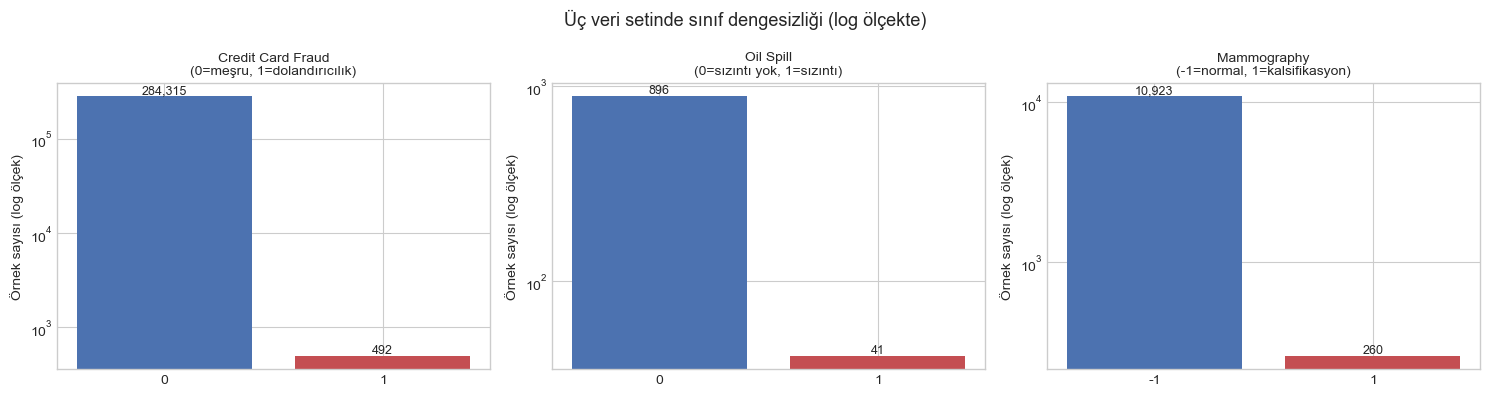

In [110]:
def imbalance_summary(y, name):
    counts = pd.Series(y).value_counts().sort_index()
    ir = counts.max() / counts.min()
    minority_pct = 100 * counts.min() / counts.sum()
    print(f"{name:22s} | toplam={counts.sum():>7d} | sınıflar={dict(counts)} "
          f"| IR=1:{ir:6.1f} | azınlık oranı=%{minority_pct:.3f}")
    return ir

ir_cc = imbalance_summary(df_cc["Class"], "Credit Card Fraud")
ir_oil = imbalance_summary(df_oil_raw.iloc[:, -1], "Oil Spill (ham)")
ir_mam = imbalance_summary(df_mam_raw[6], "Mammography")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (y, name) in zip(axes, [
    (df_cc["Class"], "Credit Card Fraud\n(0=meşru, 1=dolandırıcılık)"),
    (df_oil_raw.iloc[:, -1], "Oil Spill\n(0=sızıntı yok, 1=sızıntı)"),
    (df_mam_raw[6], "Mammography\n(-1=normal, 1=kalsifikasyon)"),
]):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=["#4C72B0", "#C44E52"])
    ax.set_title(name, fontsize=10)
    ax.set_yscale("log")
    ax.set_ylabel("Örnek sayısı (log ölçek)")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Üç veri setinde sınıf dengesizliği (log ölçekte)", fontsize=13)
plt.tight_layout()
plt.show()


## Adım 2 · Oil Spill Veri Setinin Temizlenmesi

Oil Spill veri setinin ilk sütunu bir **yama/parça kimliği (patch ID)**'dir (tahmin için anlamsız),
ve — Jason Brownlee'nin bu veri seti üzerine yazdığı klasik dengesiz-öğrenme eğitimlerinde de
belgelendiği üzere — 22. sütun **sabit (sıfır varyanslı)**'dır, yani hiçbir bilgi taşımaz. İkisini
de atıyoruz.


In [111]:
print("Sıfır varyanslı sütun(lar):", df_oil_raw.columns[df_oil_raw.nunique() == 1].tolist())

df_oil = df_oil_raw.drop(columns=[0, 22]).copy()
df_oil.columns = [f"f{i}" for i in range(df_oil.shape[1] - 1)] + ["target"]
print("Oil Spill (temiz):", df_oil.shape)
df_oil.head(3)


Sıfır varyanslı sütun(lar): [22]
Oil Spill (temiz): (937, 48)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f38,f39,f40,f41,f42,f43,f44,f45,f46,target
0,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,214.7,...,2850.0,1000.0,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,901.7,...,5750.0,11500.0,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
2,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,86.1,...,1400.0,250.0,150.00,45.13,9.33,1,31692.84,65.81,7.84,1


## Adım 3 · Temel Model ve "Doğruluk Paradoksu"

Mammography veri setinde, **hiçbir dengesizlik müdahalesi olmadan** bir Lojistik Regresyon ve bir
Random Forest eğitip, accuracy'nin ne kadar yanıltıcı olabileceğini somut olarak gösteriyoruz.


Lojistik Regresyon (baseline)    | accuracy=0.9833  precision=0.7895  recall=0.3846  f1=0.5172  gmean=0.6194
Random Forest (baseline)         | accuracy=0.9860  precision=0.8298  recall=0.5000  f1=0.6240  gmean=0.7062

'Her zaman normal de' saf modeli bile accuracy = 0.9768 elde ediyor!
--> Baseline modellerimiz bu naif modelden fazla iyi değil: yüksek accuracy, düşük recall.


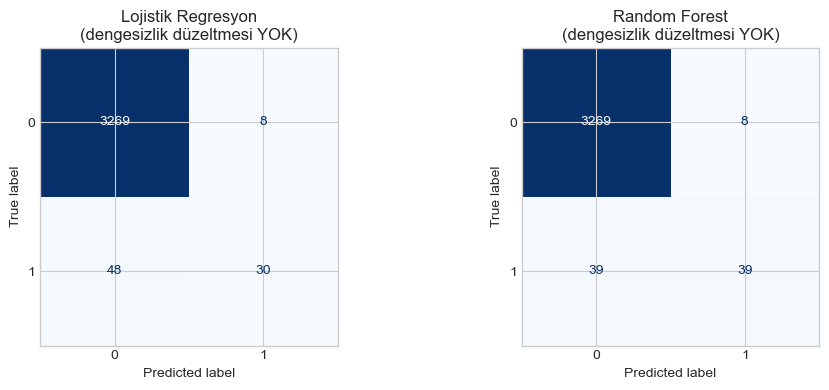

In [112]:
df_mam = df_mam_raw.copy()
df_mam.columns = [f"f{i}" for i in range(6)] + ["target"]
df_mam["target"] = (df_mam["target"] == 1).astype(int)  # 1=kalsifikasyon, 0=normal

X_mam = df_mam.drop(columns="target")
y_mam = df_mam["target"]
X_mam_tr, X_mam_te, y_mam_tr, y_mam_te = train_test_split(
    X_mam, y_mam, test_size=0.3, stratify=y_mam, random_state=RANDOM_STATE
)

baseline_results = {}
for name, clf in [
    ("Lojistik Regresyon (baseline)", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("Random Forest (baseline)", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
]:
    clf.fit(X_mam_tr, y_mam_tr)
    y_pred = clf.predict(X_mam_te)
    acc = (y_pred == y_mam_te).mean() # accuracy_score(y_mam_te, y_pred)
    rec = recall_score(y_mam_te, y_pred)
    prec = precision_score(y_mam_te, y_pred, zero_division=0)
    f1 = f1_score(y_mam_te, y_pred, zero_division=0)
    gm = gmean_score(y_mam_te, y_pred) # G-mean, dengesiz veri için standart metrik
    baseline_results[name] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1, gmean=gm)
    print(f"{name:32s} | accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}  gmean={gm:.4f}")

# "Her şeyi çoğunluk sınıfı de" modelinin accuracy'si
naive_acc = (y_mam_te == 0).mean()
print(f"\n'Her zaman normal de' saf modeli bile accuracy = {naive_acc:.4f} elde ediyor!")
print("--> Baseline modellerimiz bu naif modelden fazla iyi değil: yüksek accuracy, düşük recall.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, clf) in zip(axes, [
    ("Lojistik Regresyon", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_mam_tr, y_mam_tr)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X_mam_tr, y_mam_tr)),
]):
    ConfusionMatrixDisplay.from_estimator(clf, X_mam_te, y_mam_te, ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\n(dengesizlik düzeltmesi YOK)")
plt.tight_layout()
plt.show()


## Adım 4 · Rastgele Oversampling / Undersampling

Aynı Mammography verisinde, sadece eğitim setine `RandomOverSampler` ve `RandomUnderSampler`
uygulayıp Lojistik Regresyon'u yeniden eğitiyoruz. **Kritik:** yeniden örnekleme SADECE `X_mam_tr`
üzerinde yapılıyor — `X_mam_te` hiç dokunulmuyor (gerçek dünya dağılımını korumalı).


In [113]:
print("Eğitim seti — önce:", pd.Series(y_mam_tr).value_counts().to_dict())

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_ro, y_ro = ros.fit_resample(X_mam_tr, y_mam_tr)
print("RandomOverSampler sonrası:", pd.Series(y_ro).value_counts().to_dict())

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_ru, y_ru = rus.fit_resample(X_mam_tr, y_mam_tr)
print("RandomUnderSampler sonrası:", pd.Series(y_ru).value_counts().to_dict())

resample_results = {}
for name, (X_r, y_r) in [("Random Oversampling", (X_ro, y_ro)), ("Random Undersampling", (X_ru, y_ru))]:
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(X_r, y_r)
    y_pred = clf.predict(X_mam_te)
    resample_results[name] = dict(
        precision=precision_score(y_mam_te, y_pred, zero_division=0),
        recall=recall_score(y_mam_te, y_pred),
        f1=f1_score(y_mam_te, y_pred, zero_division=0),
        gmean=gmean_score(y_mam_te, y_pred),
    )

comparison_df = pd.DataFrame({
    "Baseline (LR)": {k: v for k, v in baseline_results["Lojistik Regresyon (baseline)"].items() if k != "accuracy"},
    **resample_results
}).T
print()
print(comparison_df.round(4))


Eğitim seti — önce: {0: 7646, 1: 182}
RandomOverSampler sonrası: {0: 7646, 1: 7646}
RandomUnderSampler sonrası: {0: 182, 1: 182}

                      precision  recall      f1   gmean
Baseline (LR)            0.7895  0.3846  0.5172  0.6194
Random Oversampling      0.1727  0.8590  0.2876  0.8802
Random Undersampling     0.1604  0.9359  0.2739  0.9093


## Adım 5 · SMOTE Ailesi: SMOTE / Borderline-SMOTE / ADASYN

Önce **sentetik 2 boyutlu bir veri seti** (`make_classification`, iki sınıf arasında kasıtlı
örtüşme ile) üzerinde üç yöntemin sentetik noktaları NEREYE yerleştirdiğini görselleştiriyoruz —
bu, teori bölümündeki formülün ($x_{new}=x_i+\lambda(x_{zi}-x_i)$) gözle görülür hali. Ardından
Mammography üzerinde gerçek performans karşılaştırmasını yapıyoruz.


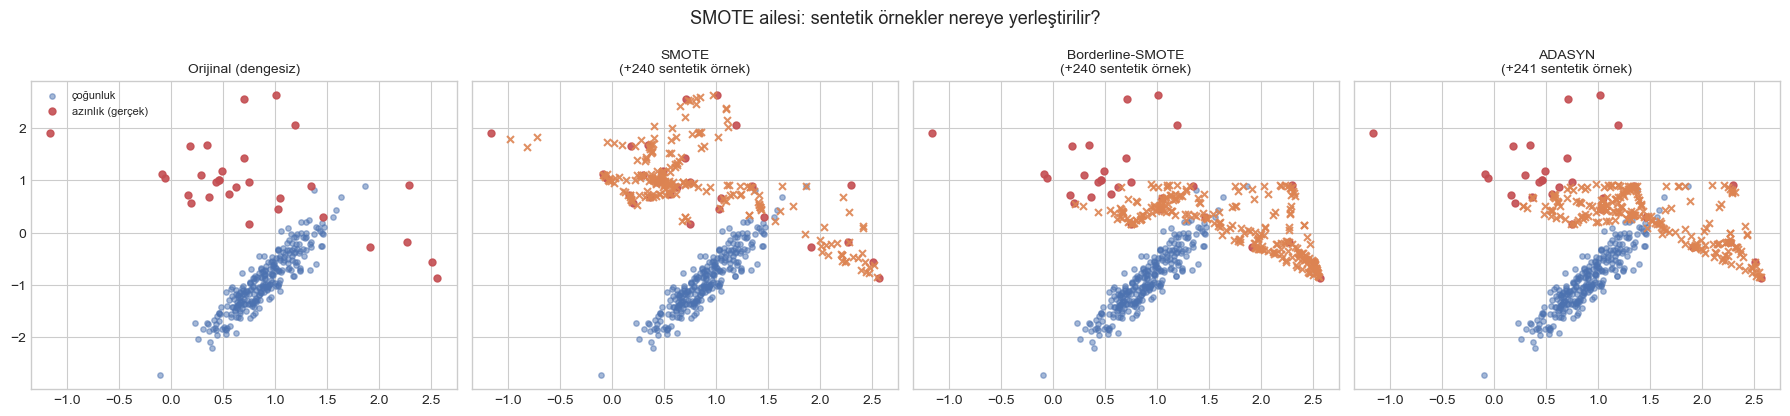

In [114]:
X_toy, y_toy = make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_clusters_per_class=1,
    weights=[0.9, 0.1], class_sep=0.9, random_state=RANDOM_STATE
)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharex=True, sharey=True)
samplers_toy = [
    ("Orijinal (dengesiz)", None),
    ("SMOTE", SMOTE(random_state=RANDOM_STATE)),
    ("Borderline-SMOTE", BorderlineSMOTE(random_state=RANDOM_STATE)),
    ("ADASYN", ADASYN(random_state=RANDOM_STATE)),
]
for ax, (name, sampler) in zip(axes, samplers_toy):
    if sampler is None:
        Xp, yp = X_toy, y_toy
        n_new = 0
    else:
        Xp, yp = sampler.fit_resample(X_toy, y_toy)
        n_new = (yp == 1).sum() - (y_toy == 1).sum()
    ax.scatter(Xp[yp == 0, 0], Xp[yp == 0, 1], s=15, alpha=0.5, label="çoğunluk", color="#4C72B0")
    ax.scatter(Xp[yp == 1, 0][: (y_toy == 1).sum()], Xp[yp == 1, 1][: (y_toy == 1).sum()],
               s=25, alpha=0.9, label="azınlık (gerçek)", color="#C44E52")
    if n_new > 0:
        ax.scatter(Xp[yp == 1, 0][(y_toy == 1).sum():], Xp[yp == 1, 1][(y_toy == 1).sum():],
                   s=25, alpha=0.9, label="azınlık (sentetik)", color="#DD8452", marker="x")
    ax.set_title(f"{name}\n(+{n_new} sentetik örnek)" if n_new else name, fontsize=10)
    if ax is axes[0]:
        ax.legend(fontsize=8, loc="upper left")
plt.suptitle("SMOTE ailesi: sentetik örnekler nereye yerleştirilir?", fontsize=13)
plt.tight_layout()
plt.show()


In [115]:
smote_results = {}
for name, sampler in [
    ("SMOTE", SMOTE(random_state=RANDOM_STATE)),
    ("Borderline-SMOTE", BorderlineSMOTE(random_state=RANDOM_STATE)),
    ("ADASYN", ADASYN(random_state=RANDOM_STATE)),
]:
    X_r, y_r = sampler.fit_resample(X_mam_tr, y_mam_tr)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_r, y_r)
    y_pred = clf.predict(X_mam_te)
    y_proba = clf.predict_proba(X_mam_te)[:, 1]
    smote_results[name] = dict(
        precision=precision_score(y_mam_te, y_pred, zero_division=0),
        recall=recall_score(y_mam_te, y_pred),
        f1=f1_score(y_mam_te, y_pred, zero_division=0),
        gmean=gmean_score(y_mam_te, y_pred),
        pr_auc=average_precision_score(y_mam_te, y_proba),
    )

smote_df = pd.DataFrame(smote_results).T
print("Mammography üzerinde SMOTE ailesi (Lojistik Regresyon ile):")
print(smote_df.round(4))


Mammography üzerinde SMOTE ailesi (Lojistik Regresyon ile):
                  precision  recall      f1   gmean  pr_auc
SMOTE                0.1885  0.9231  0.3130  0.9142  0.5254
Borderline-SMOTE     0.1663  0.9487  0.2830  0.9172  0.4148
ADASYN               0.1130  0.9487  0.2019  0.8835  0.4372


## Adım 6 · Akıllı Undersampling Ailesi: Tomek Links / ENN / NearMiss

Oil Spill veri setinde (küçük, 937 örnek — görselleştirme ve hesaplama için ideal) hangi çoğunluk
örneklerinin silindiğini PCA ile 2 boyuta indirgeyip görselleştiriyoruz.


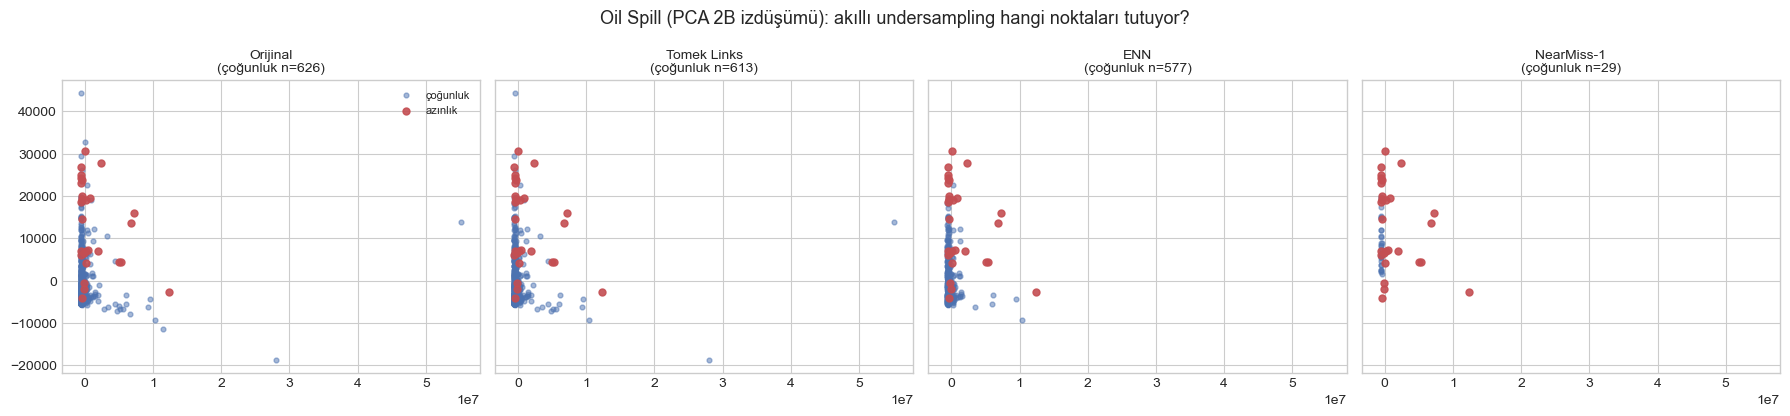

                                 precision  recall      f1   gmean
Baseline (yeniden örneklemesiz)     0.3333  0.1667  0.2222  0.4052
Tomek Links                         0.3333  0.1667  0.2222  0.4052
ENN                                 0.4286  0.2500  0.3158  0.4963
NearMiss-1                          0.0530  0.6667  0.0982  0.5600


In [116]:
X_oil = df_oil.drop(columns="target")
y_oil = df_oil["target"]
X_oil_tr, X_oil_te, y_oil_tr, y_oil_te = train_test_split(
    X_oil, y_oil, test_size=0.3, stratify=y_oil, random_state=RANDOM_STATE
)

pca_oil = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_oil_tr)

under_samplers = [
    ("Orijinal", None),
    ("Tomek Links", TomekLinks()),
    ("ENN", EditedNearestNeighbours()),
    ("NearMiss-1", NearMiss(version=1)),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharex=True, sharey=True)
under_results = {}
for ax, (name, sampler) in zip(axes, under_samplers):
    if sampler is None:
        Xr, yr = X_oil_tr, y_oil_tr
    else:
        Xr, yr = sampler.fit_resample(X_oil_tr, y_oil_tr)
    Xr_2d = pca_oil.transform(Xr)
    ax.scatter(Xr_2d[yr == 0, 0], Xr_2d[yr == 0, 1], s=12, alpha=0.5, color="#4C72B0", label="çoğunluk")
    ax.scatter(Xr_2d[yr == 1, 0], Xr_2d[yr == 1, 1], s=25, alpha=0.9, color="#C44E52", label="azınlık")
    ax.set_title(f"{name}\n(çoğunluk n={sum(yr==0)})", fontsize=10)
    if ax is axes[0]:
        ax.legend(fontsize=8)
    if sampler is not None:
        clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xr, yr)
        y_pred = clf.predict(X_oil_te)
        under_results[name] = dict(
            precision=precision_score(y_oil_te, y_pred, zero_division=0),
            recall=recall_score(y_oil_te, y_pred),
            f1=f1_score(y_oil_te, y_pred, zero_division=0),
            gmean=gmean_score(y_oil_te, y_pred),
        )
plt.suptitle("Oil Spill (PCA 2B izdüşümü): akıllı undersampling hangi noktaları tutuyor?", fontsize=13)
plt.tight_layout()
plt.show()

baseline_oil_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_oil_tr, y_oil_tr)
y_pred_oil_base = baseline_oil_clf.predict(X_oil_te)
under_results = {"Baseline (yeniden örneklemesiz)": dict(
    precision=precision_score(y_oil_te, y_pred_oil_base, zero_division=0),
    recall=recall_score(y_oil_te, y_pred_oil_base),
    f1=f1_score(y_oil_te, y_pred_oil_base, zero_division=0),
    gmean=gmean_score(y_oil_te, y_pred_oil_base),
), **under_results}
print(pd.DataFrame(under_results).T.round(4))


## Adım 7 · Hibrit Yöntemler: SMOTEENN / SMOTETomek

Mammography üzerinde saf SMOTE'u, SMOTE+ENN ve SMOTE+Tomek hibritleriyle karşılaştırıyoruz.


In [117]:
hybrid_samplers = [
    ("SMOTE (saf)", SMOTE(random_state=RANDOM_STATE)),
    ("SMOTEENN", SMOTEENN(random_state=RANDOM_STATE)),
    ("SMOTETomek", SMOTETomek(random_state=RANDOM_STATE)),
]
hybrid_results = {}
for name, sampler in hybrid_samplers:
    X_r, y_r = sampler.fit_resample(X_mam_tr, y_mam_tr)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_r, y_r)
    y_pred = clf.predict(X_mam_te)
    y_proba = clf.predict_proba(X_mam_te)[:, 1]
    hybrid_results[name] = dict(
        n_egitim_sonrasi=len(y_r),
        precision=precision_score(y_mam_te, y_pred, zero_division=0),
        recall=recall_score(y_mam_te, y_pred),
        f1=f1_score(y_mam_te, y_pred, zero_division=0),
        gmean=gmean_score(y_mam_te, y_pred),
        pr_auc=average_precision_score(y_mam_te, y_proba),
    )

hybrid_df = pd.DataFrame(hybrid_results).T
print("Mammography — SMOTE vs. hibrit temizleme yöntemleri:")
print(hybrid_df.round(4))
print("\nYORUM: ENN/Tomek temizlemesi, SMOTE'un sınıflar-arası bölgeye 'sızdırdığı' sentetik/gerçek")
print("örnekleri sildiği için eğitim seti sonrası boyutu küçülüyor ama karar sınırı netleşiyor.")


Mammography — SMOTE vs. hibrit temizleme yöntemleri:
             n_egitim_sonrasi  precision  recall      f1   gmean  pr_auc
SMOTE (saf)           15292.0     0.1885  0.9231  0.3130  0.9142  0.5254
SMOTEENN              14561.0     0.1714  0.9231  0.2892  0.9083  0.4915
SMOTETomek            15256.0     0.1885  0.9231  0.3130  0.9142  0.5257

YORUM: ENN/Tomek temizlemesi, SMOTE'un sınıflar-arası bölgeye 'sızdırdığı' sentetik/gerçek
örnekleri sildiği için eğitim seti sonrası boyutu küçülüyor ama karar sınırı netleşiyor.


## Adım 8 · Sınıf Ağırlıklandırma ve Maliyet-Duyarlı Öğrenme (Credit Card Fraud)

Artık en aşırı dengesiz veri setimize (IR≈1:578) geçiyoruz. Burada **veriyi hiç değiştirmeden**,
sadece modelin kayıp fonksiyonunu değiştiren yöntemleri karşılaştırıyoruz: `class_weight='balanced'`,
elle verilmiş bir maliyet sözlüğü, ve gradyan artırma modellerindeki `scale_pos_weight`/`is_unbalance`.


In [118]:
feature_cols_cc = [c for c in df_cc.columns if c != "Class"]
X_cc = df_cc[feature_cols_cc]
y_cc = df_cc["Class"]
X_cc_tr, X_cc_te, y_cc_tr, y_cc_te = train_test_split(
    X_cc, y_cc, test_size=0.3, stratify=y_cc, random_state=RANDOM_STATE
)
print("Eğitim:", X_cc_tr.shape, "| Test:", X_cc_te.shape)
print("Eğitimde azınlık sayısı:", (y_cc_tr == 1).sum(), "| Testte azınlık sayısı:", (y_cc_te == 1).sum())

scale_pos_weight = (y_cc_tr == 0).sum() / (y_cc_tr == 1).sum()
print(f"Önerilen scale_pos_weight (N_neg/N_pos) = {scale_pos_weight:.1f}")


Eğitim: (199364, 30) | Test: (85443, 30)
Eğitimde azınlık sayısı: 344 | Testte azınlık sayısı: 148
Önerilen scale_pos_weight (N_neg/N_pos) = 578.5


In [119]:
def evaluate(clf, X_te, y_te, name, timings=None):
    y_pred = clf.predict(X_te)
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_te)[:, 1]
    else:
        y_proba = clf.decision_function(X_te)
    res = dict(
        precision=precision_score(y_te, y_pred, zero_division=0),
        recall=recall_score(y_te, y_pred),
        f1=f1_score(y_te, y_pred, zero_division=0),
        f2=fbeta_score(y_te, y_pred, beta=2, zero_division=0),
        gmean=gmean_score(y_te, y_pred),
        balanced_acc=balanced_accuracy_score(y_te, y_pred),
        roc_auc=roc_auc_score(y_te, y_proba),
        pr_auc=average_precision_score(y_te, y_proba),
        specificity=confusion_matrix(y_te, y_pred).ravel()[0] / (confusion_matrix(y_te, y_pred).ravel()[0] + confusion_matrix(y_te, y_pred).ravel()[1]),
    )
    if timings is not None:
        res["egitim_suresi_sn"] = timings
    return res

weighting_results = {}

t0 = time.time()
clf_plain = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_cc_tr, y_cc_tr)
weighting_results["Baseline (ağırlık yok)"] = evaluate(clf_plain, X_cc_te, y_cc_te, "baseline", time.time() - t0)

t0 = time.time()
clf_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE).fit(X_cc_tr, y_cc_tr)
weighting_results["class_weight='balanced' (LR)"] = evaluate(clf_bal, X_cc_te, y_cc_te, "balanced", time.time() - t0)

t0 = time.time()
clf_manual = LogisticRegression(max_iter=1000, class_weight={0: 1, 1: 50}, random_state=RANDOM_STATE).fit(X_cc_tr, y_cc_tr)
weighting_results["class_weight={0:1,1:50} (LR)"] = evaluate(clf_manual, X_cc_te, y_cc_te, "manual", time.time() - t0)

t0 = time.time()
clf_rf_bal = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1).fit(X_cc_tr, y_cc_tr)
weighting_results["class_weight='balanced' (RF)"] = evaluate(clf_rf_bal, X_cc_te, y_cc_te, "rf_balanced", time.time() - t0)

t0 = time.time()
clf_xgb = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1, scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1
).fit(X_cc_tr, y_cc_tr)
weighting_results["scale_pos_weight (XGBoost)"] = evaluate(clf_xgb, X_cc_te, y_cc_te, "xgb", time.time() - t0)

weighting_df = pd.DataFrame(weighting_results).T
print(weighting_df.round(4))


                              precision  recall      f1      f2   gmean  \
Baseline (ağırlık yok)           0.8636  0.6419  0.7364  0.6766  0.8011   
class_weight='balanced' (LR)     0.0578  0.8716  0.1084  0.2284  0.9220   
class_weight={0:1,1:50} (LR)     0.3727  0.8311  0.5146  0.6670  0.9105   
class_weight='balanced' (RF)     0.9722  0.7095  0.8203  0.7500  0.8423   
scale_pos_weight (XGBoost)       0.7066  0.7973  0.7492  0.7773  0.8927   

                              balanced_acc  roc_auc  pr_auc  specificity  \
Baseline (ağırlık yok)              0.8209   0.9310  0.6572       0.9998   
class_weight='balanced' (LR)        0.9235   0.9659  0.7045       0.9753   
class_weight={0:1,1:50} (LR)        0.9143   0.9588  0.7068       0.9976   
class_weight='balanced' (RF)        0.8547   0.9333  0.8104       1.0000   
scale_pos_weight (XGBoost)          0.8984   0.9745  0.8221       0.9994   

                              egitim_suresi_sn  
Baseline (ağırlık yok)                 10.9

**LightGBM'in `is_unbalance`/`scale_pos_weight` parametreleri de aynı mantıkla çalışır** —
farklılık göstermesi için burada Mammography (daha küçük, 11.183 satır) veri setinde, Adım 3'teki
Random Forest temeliyle karşılaştırıyoruz.


In [120]:
t0 = time.time()
clf_lgb = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.1, is_unbalance=True,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
).fit(X_mam_tr, y_mam_tr)
lgb_res = evaluate(clf_lgb, X_mam_te, y_mam_te, "lgb", time.time() - t0)

print("Mammography — RF (class_weight yok, Adım 3'ten)         :",
      {k: round(v, 4) for k, v in baseline_results["Random Forest (baseline)"].items() if k in ("precision", "recall", "f1", "gmean")})
print("Mammography — LightGBM (is_unbalance=True)              :",
      {k: round(v, 4) for k, v in lgb_res.items() if k in ("precision", "recall", "f1", "gmean")})


Mammography — RF (class_weight yok, Adım 3'ten)         : {'precision': 0.8298, 'recall': 0.5, 'f1': 0.624, 'gmean': np.float64(0.7062)}
Mammography — LightGBM (is_unbalance=True)              : {'precision': 0.7073, 'recall': 0.7436, 'f1': 0.725, 'gmean': np.float64(0.8592)}


## Adım 9 · Karar Eşiği Taşıma (Threshold Moving)

`class_weight='balanced'` (LR) modeli, varsayılan $0.5$ eşiğiyle precision'ı feda edip recall'u
%87'ye çıkarmıştı. Şimdi **aynı modeli hiç değiştirmeden**, sadece eşiği tarayarak
precision/recall/F1/F2'nin nasıl değiştiğini görüyor ve $F_2$'yi (recall ağırlıklı) maksimize
eden eşiği buluyoruz — dolandırıcılık teşhisinde bir vakayı kaçırmanın maliyeti yüksek olduğu için.


Varsayılan eşik (0.5)  -> precision=0.8636, recall=0.6419
F2-optimal eşik (0.104) -> precision=0.7333, recall=0.7432, F2=0.7412


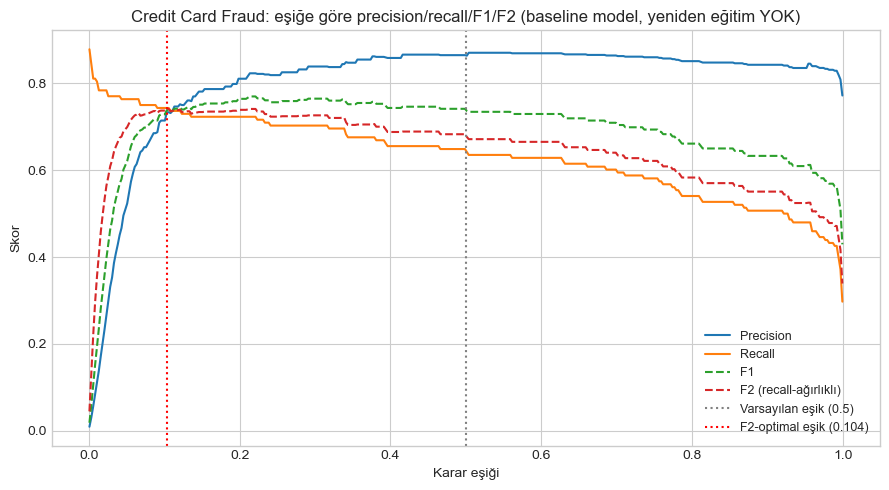

In [121]:
y_proba_base = clf_plain.predict_proba(X_cc_te)[:, 1]  # ağırlıksız baseline model

thresholds = np.linspace(0.001, 0.999, 400)
th_precision, th_recall, th_f1, th_f2 = [], [], [], []
for t in thresholds:
    y_pred_t = (y_proba_base >= t).astype(int)
    th_precision.append(precision_score(y_cc_te, y_pred_t, zero_division=0))
    th_recall.append(recall_score(y_cc_te, y_pred_t))
    th_f1.append(f1_score(y_cc_te, y_pred_t, zero_division=0))
    th_f2.append(fbeta_score(y_cc_te, y_pred_t, beta=2, zero_division=0))

best_f2_idx = int(np.argmax(th_f2))
best_f2_threshold = thresholds[best_f2_idx]
print(f"Varsayılan eşik (0.5)  -> precision={th_precision[np.searchsorted(thresholds, 0.5)]:.4f}, "
      f"recall={th_recall[np.searchsorted(thresholds, 0.5)]:.4f}")
print(f"F2-optimal eşik ({best_f2_threshold:.3f}) -> precision={th_precision[best_f2_idx]:.4f}, "
      f"recall={th_recall[best_f2_idx]:.4f}, F2={th_f2[best_f2_idx]:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, th_precision, label="Precision")
ax.plot(thresholds, th_recall, label="Recall")
ax.plot(thresholds, th_f1, label="F1", linestyle="--")
ax.plot(thresholds, th_f2, label="F2 (recall-ağırlıklı)", linestyle="--")
ax.axvline(0.5, color="gray", linestyle=":", label="Varsayılan eşik (0.5)")
ax.axvline(best_f2_threshold, color="red", linestyle=":", label=f"F2-optimal eşik ({best_f2_threshold:.3f})")
ax.set_xlabel("Karar eşiği")
ax.set_ylabel("Skor")
ax.set_title("Credit Card Fraud: eşiğe göre precision/recall/F1/F2 (baseline model, yeniden eğitim YOK)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Adım 10 · Dengesizliğe Duyarlı Ensemble Yöntemleri

Mammography üzerinde `imbalanced-learn`'ün üç özel ensemble sınıflandırıcısını, Adım 3'teki plain
Random Forest temeliyle karşılaştırıyoruz: **BalancedRandomForestClassifier**,
**EasyEnsembleClassifier** ve **RUSBoostClassifier**.


In [174]:
ensemble_clfs = {
    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Easy Ensemble": EasyEnsembleClassifier(
        n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "RUSBoost": RUSBoostClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
}

ensemble_results = {"Random Forest (baseline, Adım 3)": {
    k: v for k, v in baseline_results["Random Forest (baseline)"].items() if k != "accuracy"
}}
for name, clf in ensemble_clfs.items():
    t0 = time.time()
    clf.fit(X_mam_tr, y_mam_tr)
    y_pred = clf.predict(X_mam_te)
    y_proba = clf.predict_proba(X_mam_te)[:, 1]
    ensemble_results[name] = dict(
        precision=precision_score(y_mam_te, y_pred, zero_division=0),
        recall=recall_score(y_mam_te, y_pred),
        f1=f1_score(y_mam_te, y_pred, zero_division=0),
        gmean=gmean_score(y_mam_te, y_pred),
        pr_auc=average_precision_score(y_mam_te, y_proba),
        egitim_suresi_sn=time.time() - t0,
    )

ensemble_df = pd.DataFrame(ensemble_results).T
print(ensemble_df.round(4))


                                  precision  recall      f1   gmean  pr_auc  \
Random Forest (baseline, Adım 3)     0.8298  0.5000  0.6240  0.7062     NaN   
Balanced Random Forest               0.3070  0.8974  0.4575  0.9242  0.6911   
Easy Ensemble                        0.1596  0.9231  0.2722  0.9035  0.6659   
RUSBoost                             0.1615  0.7308  0.2645  0.8153  0.2908   

                                  egitim_suresi_sn  
Random Forest (baseline, Adım 3)               NaN  
Balanced Random Forest                      0.2422  
Easy Ensemble                               0.2796  
RUSBoost                                    0.0122  


## Adım 11 · KRİTİK: Doğru Çapraz Doğrulama vs. Veri Sızıntısı Tuzağı

Teori bölüm 10'da anlatılan tuzağı, Oil Spill veri setinde (küçük olduğu için hızlı çoklu CV
mümkün) **somut sayılarla** gösteriyoruz. Aynı model (SMOTE + Lojistik Regresyon), aynı veri, aynı
5-katlamalı `StratifiedKFold` — TEK fark, SMOTE'un ne zaman uygulandığı:

- **YANLIŞ:** SMOTE tüm veriye önce uygulanır, SONRA `cross_val_score` çağrılır (sklearn'ün
  standart `Pipeline`'ı `fit_resample`'ı desteklemediği için bu hata, "SMOTE'u elle uygulayıp
  sonra normal `Pipeline`/`cross_val_score` kullanma" şeklinde de ortaya çıkabilir).
- **DOĞRU:** `imblearn.pipeline.Pipeline([("smote", SMOTE()), ("clf", LogisticRegression())])`
  kullanılır ve orijinal (yeniden örneklenmemiş) `X_oil, y_oil` bu pipeline'a verilir —
  `cross_val_score` her katlamada SMOTE'u SADECE o katlamanın eğitim kısmına uygular.


YANLIŞ (sızıntılı) CV F1  : 0.9193 ± 0.0052  [0.914 0.929 0.916 0.918 0.92 ]
DOĞRU (pipeline içi) CV F1: 0.4159 ± 0.0558  [0.462 0.308 0.438 0.452 0.421]
Hiç resample yok CV F1    : 0.4452 ± 0.1528  [0.267 0.545 0.667 0.462 0.286]

--> Veri sızıntısı, F1 skorunu +0.5034 puan YAPAY OLARAK ŞİŞİRİYOR (%121.0 göreli fark)!
    Üretimde bu şişirilmiş skora güvenip modeli devreye alan bir ekip, gerçek dünyada
    çok daha kötü bir performansla karşılaşır.


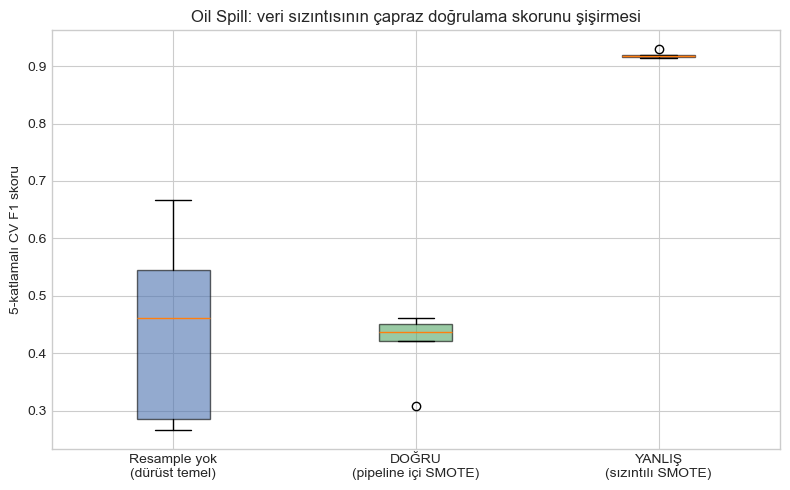

In [123]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- YANLIŞ: önce tüm veriye SMOTE, sonra CV ---
smote_leak = SMOTE(random_state=RANDOM_STATE)
X_oil_smote_all, y_oil_smote_all = smote_leak.fit_resample(X_oil, y_oil)
wrong_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_oil_smote_all, y_oil_smote_all, cv=cv, scoring="f1"
)

# --- DOĞRU: SMOTE, imblearn Pipeline içinde, her katlamada sadece eğitim kısmına ---
correct_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
correct_scores = cross_val_score(correct_pipeline, X_oil, y_oil, cv=cv, scoring="f1")

# --- Karşılaştırma için: hiç yeniden örnekleme yapmadan CV ---
no_resample_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_oil, y_oil, cv=cv, scoring="f1"
)

print(f"YANLIŞ (sızıntılı) CV F1  : {wrong_scores.mean():.4f} ± {wrong_scores.std():.4f}  {np.round(wrong_scores, 3)}")
print(f"DOĞRU (pipeline içi) CV F1: {correct_scores.mean():.4f} ± {correct_scores.std():.4f}  {np.round(correct_scores, 3)}")
print(f"Hiç resample yok CV F1    : {no_resample_scores.mean():.4f} ± {no_resample_scores.std():.4f}  {np.round(no_resample_scores, 3)}")
print()
inflation = wrong_scores.mean() - correct_scores.mean()
print(f"--> Veri sızıntısı, F1 skorunu {inflation:+.4f} puan YAPAY OLARAK ŞİŞİRİYOR "
      f"(%{100*inflation/correct_scores.mean():.1f} göreli fark)!")
print("    Üretimde bu şişirilmiş skora güvenip modeli devreye alan bir ekip, gerçek dünyada")
print("    çok daha kötü bir performansla karşılaşır.")

fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [no_resample_scores, correct_scores, wrong_scores]
labels_to_plot = ["Resample yok\n(dürüst temel)", "DOĞRU\n(pipeline içi SMOTE)", "YANLIŞ\n(sızıntılı SMOTE)"]
bp = ax.boxplot(data_to_plot, tick_labels=labels_to_plot, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#55A868", "#C44E52"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("5-katlamalı CV F1 skoru")
ax.set_title("Oil Spill: veri sızıntısının çapraz doğrulama skorunu şişirmesi")
plt.tight_layout()
plt.show()


## Adım 12 · Büyük Karşılaştırma Tablosu (Credit Card Fraud)

Şimdiye kadar gördüğümüz **hemen her tekniği** aynı veri setinde (Credit Card Fraud, aynı
train/test bölünmesi) yan yana koyuyoruz. **Pratik bir not:** komşuluk-tabanlı temizleme
yöntemlerini (Tomek Links, ENN, NearMiss ve bunların SMOTE ile hibritleri — SMOTEENN/SMOTETomek)
bu tabloya **dahil etmiyoruz** — çünkü bu yöntemler her azınlık/çoğunluk örneği için en-yakın-komşu
araması gerektirir ve 199.364 satırlık bu eğitim setinde (sadece Tomek Links'in kendisi ~90
saniye sürdü, SMOTETomek 2 dakikayı aştı) üretim ölçeğinde pratik değildir — bu yüzden onları
Adım 6-7'de çok daha küçük (Oil Spill, Mammography) veri setlerinde gösterdik. Bu, gerçek dünyada
teknik seçerken hesaplama maliyetinin de bir karar kriteri olduğunun somut bir örneğidir.


In [124]:
def fit_eval_resampler(sampler, X_tr, y_tr, X_te, y_te, base_clf=None):
    if base_clf is None:
        base_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    t0 = time.time()
    X_r, y_r = sampler.fit_resample(X_tr, y_tr)
    base_clf.fit(X_r, y_r)
    return evaluate(base_clf, X_te, y_te, "", time.time() - t0)

big_results = {}
big_results["Baseline (hiçbir müdahale yok)"] = weighting_results["Baseline (ağırlık yok)"]
big_results["Random Oversampling"] = fit_eval_resampler(RandomOverSampler(random_state=RANDOM_STATE), X_cc_tr, y_cc_tr, X_cc_te, y_cc_te)
big_results["Random Undersampling"] = fit_eval_resampler(RandomUnderSampler(random_state=RANDOM_STATE), X_cc_tr, y_cc_tr, X_cc_te, y_cc_te)
big_results["SMOTE"] = fit_eval_resampler(SMOTE(random_state=RANDOM_STATE), X_cc_tr, y_cc_tr, X_cc_te, y_cc_te)
big_results["Borderline-SMOTE"] = fit_eval_resampler(BorderlineSMOTE(random_state=RANDOM_STATE), X_cc_tr, y_cc_tr, X_cc_te, y_cc_te)
big_results["ADASYN"] = fit_eval_resampler(ADASYN(random_state=RANDOM_STATE), X_cc_tr, y_cc_tr, X_cc_te, y_cc_te)
big_results["class_weight='balanced' (LR)"] = weighting_results["class_weight='balanced' (LR)"]
big_results["class_weight={0:1,1:50} (LR)"] = weighting_results["class_weight={0:1,1:50} (LR)"]
big_results["class_weight='balanced' (RF)"] = weighting_results["class_weight='balanced' (RF)"]
big_results["scale_pos_weight (XGBoost)"] = weighting_results["scale_pos_weight (XGBoost)"]

t0 = time.time()
brf = BalancedRandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1).fit(X_cc_tr, y_cc_tr)
big_results["Balanced Random Forest"] = evaluate(brf, X_cc_te, y_cc_te, "", time.time() - t0)

t0 = time.time()
eec = EasyEnsembleClassifier(n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1).fit(X_cc_tr, y_cc_tr)
big_results["Easy Ensemble"] = evaluate(eec, X_cc_te, y_cc_te, "", time.time() - t0)

big_df = pd.DataFrame(big_results).T.drop(columns=["egitim_suresi_sn"]).rename(
    columns=dict(precision="Precision", recall="Recall", f1="F1", f2="F2", gmean="G-mean",
                 balanced_acc="Balanced Acc.", roc_auc="ROC-AUC", pr_auc="PR-AUC")
)
big_df = big_df.sort_values("PR-AUC", ascending=False)
big_df.round(4)


,Precision,Recall,F1,F2,G-mean,Balanced Acc.,ROC-AUC,PR-AUC,specificity
scale_pos_weight (XGBoost),0.7066,0.7973,0.7492,0.7773,0.8927,0.8984,0.9745,0.8221,0.9994
class_weight='balanced' (RF),0.9722,0.7095,0.8203,0.7500,0.8423,0.8547,0.9333,0.8104,1.0000
Balanced Random Forest,0.1462,0.8514,0.2495,0.4333,0.9187,0.9214,0.9743,0.7596,0.9914
SMOTE,0.1199,0.8514,0.2102,0.3834,0.9177,0.9203,0.9629,0.7163,0.9892
"class_weight={0:1,1:50} (LR)",0.3727,0.8311,0.5146,0.6670,0.9105,0.9143,0.9588,0.7068,0.9976
ADASYN,0.1118,0.8514,0.1976,0.3665,0.9173,0.9198,0.9606,0.7062,0.9883
class_weight='balanced' (LR),0.0578,0.8716,0.1084,0.2284,0.9220,0.9235,0.9659,0.7045,0.9753
Random Oversampling,0.0558,0.8716,0.1049,0.2221,0.9216,0.9230,0.9668,0.6992,0.9744
Easy Ensemble,0.0510,0.8784,0.0964,0.2070,0.9238,0.9250,0.9701,0.6926,0.9717
Baseline (hiçbir müdahale yok),0.8636,0.6419,0.7364,0.6766,0.8011,0.8209,0.9310,0.6572,0.9998


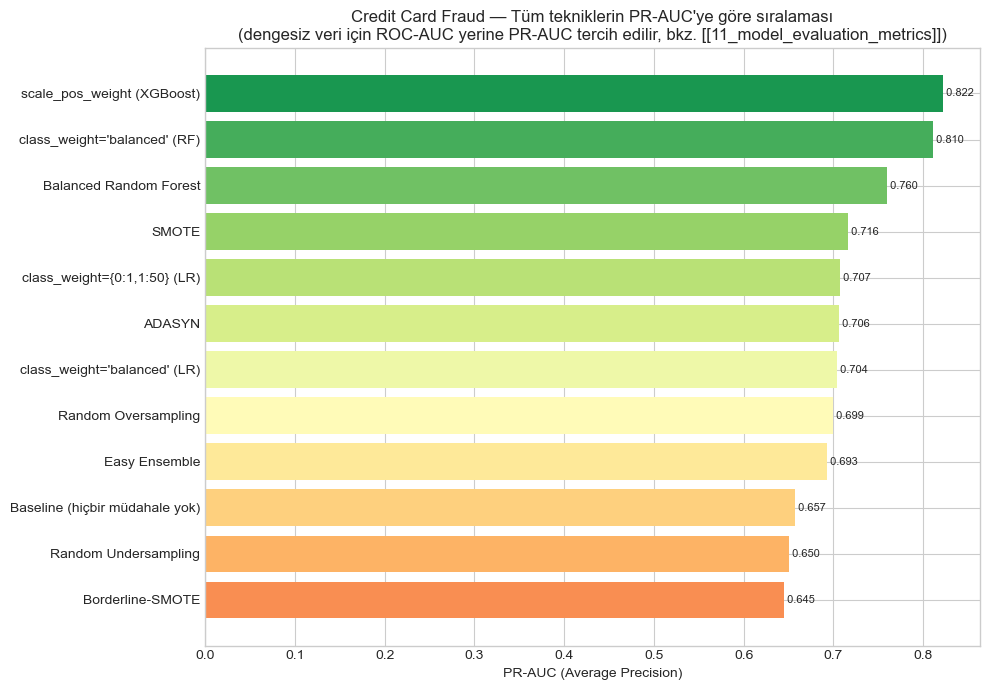

En yüksek PR-AUC: scale_pos_weight (XGBoost) (0.8221)
En yüksek Recall: Random Undersampling (0.8851)
En yüksek Precision (baseline hariç): class_weight='balanced' (RF) (0.9722)


In [125]:
fig, ax = plt.subplots(figsize=(10, 7))
order = big_df["PR-AUC"].sort_values()
colors = plt.cm.RdYlGn(np.linspace(0.25, 0.9, len(order)))
ax.barh(order.index, order.values, color=colors)
ax.set_xlabel("PR-AUC (Average Precision)")
ax.set_title("Credit Card Fraud — Tüm tekniklerin PR-AUC'ye göre sıralaması\n"
             "(dengesiz veri için ROC-AUC yerine PR-AUC tercih edilir, bkz. [[11_model_evaluation_metrics]])")
for i, v in enumerate(order.values):
    ax.text(v, i, f" {v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print("En yüksek PR-AUC:", big_df['PR-AUC'].idxmax(), f"({big_df['PR-AUC'].max():.4f})")
print("En yüksek Recall:", big_df['Recall'].idxmax(), f"({big_df['Recall'].max():.4f})")
print("En yüksek Precision (baseline hariç):",
      big_df.drop(index='Baseline (hiçbir müdahale yok)')['Precision'].idxmax(),
      f"({big_df.drop(index='Baseline (hiçbir müdahale yok)')['Precision'].max():.4f})")


## Adım 13 · Sentez: Hangi Durumda Hangi Yöntem?

| Durum | Önerilen ilk adım |
|---|---|
| Hızlı bir temel çizgi / prototip lazım | `class_weight='balanced'` — hiçbir veri değişikliği gerektirmez, tek satır kod |
| Gradyan artırma kullanıyorsunuz (XGBoost/LightGBM/CatBoost) | `scale_pos_weight` / `is_unbalance` — yerleşik ve optimize edilmiş |
| Veri seti küçük/orta (~onbinlerce satır), sentetik örnek üretmek mantıklı | SMOTE / Borderline-SMOTE / ADASYN — sınıflar örtüşüyorsa SMOTEENN/SMOTETomek |
| Veri seti çok büyük (milyonlarca satır), hesaplama maliyeti kritik | Random Undersampling (hızlı) veya sınıf ağırlıklandırma (veriye dokunmaz) — Tomek/ENN gibi $O(n\log n)$+ komşuluk yöntemlerinden kaçının |
| Recall kritik önemde (dolandırıcılık, hastalık taraması) ve model zaten eğitilmiş | Eşik taşıma (threshold moving) — en ucuz, en hızlı müdahale |
| Undersampling'in bilgi kaybından endişe ediliyor | Balanced Random Forest / EasyEnsemble / RUSBoost — çoklu alt-örneklemle telafi |
| İş biriminden somut bir maliyet matrisi var (örn. $ cinsinden) | Doğrudan maliyet minimizasyonuna dayalı eşik seçimi (bu notebook'un SQL bölümünde göreceğiz) |

**Ve en önemlisi (Adım 10-11'i tekrar hatırlatalım):** Hangi tekniği seçerseniz seçin, yeniden
örnekleme adımını **her zaman `imblearn.pipeline.Pipeline` içinde, çapraz doğrulamanın parçası
olarak** çalıştırın — asla tüm veriye önceden uygulamayın. Bu tek kural, bu notebook'taki tüm diğer
tekniklerden daha çok gerçek dünya performansını etkiler.


# 📊 R Uygulaması

`imbalanced-learn`'ün R karşılığı tek bir kütüphane değildir — R ekosisteminde bu iş birkaç paket
arasında dağılmıştır: **`ROSE`** (rastgele/sentetik over-under sampling), **`smotefamily`**
(SMOTE/ADASYN), **`unbalanced`** (Tomek/ENN/NCL/kombine yöntemler — ilginç bir not: bu paketin
yazarlarından Andrea Dal Pozzolo, bu notebook'ta kullandığımız **Credit Card Fraud veri setinin de
yaratıcısıdır**), **`randomForest`** (sınıf ağırlıklandırma + dengeli örnekleme), **`ebmc`**
(RUSBoost/SMOTEBoost tipi ensemble'lar), **`caret`** (doğru CV içi örnekleme) ve **`pROC`**
(eşik seçimi — [[11_model_evaluation_metrics]]'te de kullanmıştık).

Credit Card Fraud'un tamamını (285K satır) rpy2 üzerinden R'a aktarmak yerine, R bölümünde
**stratified bir alt örneklem** (5.000 meşru + 492 dolandırıcılık işleminin tamamı) kullanıyoruz —
amaç R'daki kavramsal karşılığı göstermek, ölçek performansı kıyaslamak değil.


In [126]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [127]:
cc_sample = pd.concat([
    df_cc[df_cc["Class"] == 1],
    df_cc[df_cc["Class"] == 0].sample(n=5000, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print("R için Credit Card alt örneklemi:", cc_sample.shape, dict(cc_sample["Class"].value_counts()))


R için Credit Card alt örneklemi: (5492, 31) {0: np.int64(5000), 1: np.int64(492)}


In [128]:
%%R -i df_mam -i df_oil -i cc_sample
suppressMessages({
  library(ROSE)
  library(smotefamily)
  library(unbalanced)
  library(randomForest)
  library(pROC)
})
df_mam$target <- as.factor(df_mam$target)
df_oil$target <- as.factor(df_oil$target)
cc_sample$Class <- as.factor(cc_sample$Class)
cat("Mammography:", dim(df_mam), "\n")
cat("Oil Spill  :", dim(df_oil), "\n")
cat("CC örneklem:", dim(cc_sample), "\n")


Mammography: 11183 7 
Oil Spill  : 937 48 
CC örneklem: 5492 31 


### R · Temel Model ve Doğruluk Paradoksu


In [129]:
%%R
set.seed(42)
idx <- sample(seq_len(nrow(df_mam)), size = 0.7 * nrow(df_mam))
train <- df_mam[idx, ]; test <- df_mam[-idx, ]

rf_baseline <- randomForest(target ~ ., data = train, ntree = 200)
pred <- predict(rf_baseline, test)
acc <- mean(pred == test$target)
cat("Baseline RF accuracy:", round(acc, 4), "\n")
print(table(Gercek = test$target, Tahmin = pred))
cat("Naif ('her zaman normal') accuracy:", round(mean(test$target == 0), 4), "\n")


Baseline RF accuracy: 0.9908 
      Tahmin
Gercek    0    1
     0 3279    4
     1   27   45
Naif ('her zaman normal') accuracy: 0.9785 


### R · Rastgele Over/Undersampling (`ROSE::ovun.sample`) ve Sentetik Oversampling (`ROSE::ROSE`)


In [130]:
%%R
train_over  <- ovun.sample(target ~ ., data = train, method = "over",  N = 2 * sum(train$target == 0))$data
train_under <- ovun.sample(target ~ ., data = train, method = "under", N = 2 * sum(train$target == 1))$data
train_rose  <- ROSE(target ~ ., data = train, seed = 42)$data  # ROSE: çekirdek-tabanlı sentetik örnekleme

cat("Over  :", table(train_over$target), "\n")
cat("Under :", table(train_under$target), "\n")
cat("ROSE  :", table(train_rose$target), "\n")

for (nm in c("train_over", "train_under", "train_rose")) {
  d <- get(nm)
  m <- randomForest(target ~ ., data = d, ntree = 200)
  p <- predict(m, test)
  cm <- table(test$target, p)
  recall <- cm[2, 2] / sum(cm[2, ])
  precision <- cm[2, 2] / sum(cm[, 2])
  cat(sprintf("%-12s recall=%.4f  precision=%.4f\n", nm, recall, precision))
}


Over  : 7640 7640 
Under : 188 188 
ROSE  : 3905 3923 
train_over   recall=0.6111  precision=0.8148
train_under  recall=0.8333  precision=0.1681
train_rose   recall=0.8056  precision=0.2042


### R · SMOTE Ailesi (`smotefamily::SMOTE` / `ADAS`)


In [131]:
%%R
train_num <- train
train_num$target <- as.numeric(as.character(train$target))

smote_out  <- SMOTE(train_num[, -ncol(train_num)], train_num$target, K = 5)
adasyn_out <- ADAS(train_num[, -ncol(train_num)], train_num$target, K = 5)

cat("SMOTE sonrası sınıf dağılımı:\n"); print(table(smote_out$data$class))
cat("ADASYN sonrası sınıf dağılımı:\n"); print(table(adasyn_out$data$class))
# smote_out$data / adasyn_out$data üzerinde randomForest/glm eğitimi Python'daki Adım 5 ile birebir aynı mantık


SMOTE sonrası sınıf dağılımı:

   0    1 
7640 7520 
ADASYN sonrası sınıf dağılımı:

   0    1 
7640 7600 


### R · Akıllı Undersampling (`unbalanced::ubTomek`, `ubENN`, `ubNCL`)


In [132]:
%%R
oil_num <- df_oil
oil_num$target <- as.numeric(as.character(df_oil$target))
X_oil_r <- oil_num[, -ncol(oil_num)]
Y_oil_r <- oil_num$target

tomek_out <- ubTomek(X_oil_r, Y_oil_r)
enn_out   <- ubENN(X_oil_r, Y_oil_r)
ncl_out   <- ubNCL(X_oil_r, Y_oil_r)  # Neighborhood Cleaning Rule — ENN'in bir varyasyonu

cat("Orijinal çoğunluk n     :", sum(Y_oil_r == 0), "\n")
cat("Tomek sonrası çoğunluk n:", sum(tomek_out$Y == 0), "\n")
cat("ENN sonrası çoğunluk n  :", sum(enn_out$Y == 0), "\n")
cat("NCL sonrası çoğunluk n  :", sum(ncl_out$Y == 0), "\n")


Instances removed 34 : 3.79 % of 0 class ; 3.63 % of training ; Time needed 0 
Number of instances removed from majority class with ENN: 1 	 Time needed: 0.03 
Number of instances removed from majority class with ENN: 1 	 Time needed: 0.03 
Number of instances removed from majority class after ENN: 76 	 Time needed: 0 
Number of instances removed from majority class: 77 
Orijinal çoğunluk n     : 896 
Tomek sonrası çoğunluk n: 862 
ENN sonrası çoğunluk n  : 895 
NCL sonrası çoğunluk n  : 819 


### R · Hibrit Yöntem (`unbalanced::ubSMOTE` — kombine over+under)


In [133]:
%%R
Y_oil_r <- as.factor(Y_oil_r)
hybrid_out <- ubSMOTE(X_oil_r, Y_oil_r, perc.over = 300, perc.under = 150, k = 5)
cat("ubSMOTE (hibrit) sonrası sınıf dağılımı:\n")
print(table(hybrid_out$Y))
# perc.over=300: azınlığı 3 katına sentetik olarak büyüt; perc.under=150: çoğunluktan orantılı azalt
# --> Python'daki SMOTEENN/SMOTETomek'in kavramsal karşılığı: önce zenginleştir, sonra temizle/dengele


ubSMOTE (hibrit) sonrası sınıf dağılımı:

  0   1 
184 164 


### R · Sınıf Ağırlıklandırma (`randomForest(classwt=...)`, `glm(weights=...)`, R `xgboost`)


In [134]:
%%R
suppressMessages(library(xgboost))

rf_weighted <- randomForest(target ~ ., data = train, ntree = 200,
                             classwt = c("0" = 1, "1" = nrow(train) / sum(train$target == 1)))
pred_w <- predict(rf_weighted, test)
cat("classwt ile ağırlıklı RF:\n"); print(table(test$target, pred_w))

# glm'de gözlem ağırlığı ile maliyet-duyarlı lojistik regresyon
w <- ifelse(train$target == 1, nrow(train) / (2 * sum(train$target == 1)),
                                 nrow(train) / (2 * sum(train$target == 0)))
glm_weighted <- glm(target ~ ., data = train, family = binomial, weights = w)

train_label <- as.numeric(as.character(train$target))
# xgboost R paketi: scale_pos_weight PYTHON İLE AYNI C++ çekirdeğini kullanır (bkz. [[gradient_boosting_family]])
dtrain <- xgb.DMatrix(data = data.matrix(train[, -ncol(train)]), label = train_label)
spw <- sum(train_label == 0) / sum(train_label == 1)
params <- list(max_depth = 4, learning_rate = 0.1, nthread = 4, objective = "binary:logistic", scale_pos_weight = spw)
xgb_weighted <- xgb.train(data = dtrain, params = params, nrounds = 200, verbose = FALSE)
cat("xgboost (R) scale_pos_weight =", round(spw, 1), "ile eğitildi.\n")


classwt ile ağırlıklı RF:
   pred_w
       0    1
  0 2242 1041
  1   32   40
xgboost (R) scale_pos_weight = 40.6 ile eğitildi.


In addition: Warning messages:
1: In eval(family$initialize) : non-integer #successes in a binomial glm!
2: glm.fit: fitted probabilities numerically 0 or 1 occurred 


### R · Eşik Taşıma (`pROC::coords`)


In [135]:
%%R
probs <- predict(rf_baseline, test, type = "prob")[, "1"]
roc_obj <- roc(test$target, probs, quiet = TRUE)
best <- coords(roc_obj, "best", best.method = "youden", ret = c("threshold", "precision", "recall"))
cat("Youden J ile optimal eşik:\n"); print(best)
# F-beta'ya göre eşik taraması için: farklı eşiklerde table(test$target, probs > t) ile
# precision/recall elle hesaplanıp Python'daki F2 taramasının birebir aynısı R'da da yapılabilir.


Youden J ile optimal eşik:
          threshold precision    recall
threshold    0.1025 0.4255319 0.8333333


### R · Dengesizliğe Duyarlı Ensemble (native `randomForest(sampsize=..., strata=...)`, `ebmc::rus`)


In [136]:
%%R
suppressMessages(library(ebmc))

# randomForest'ın 'strata'+'sampsize' argümanları TAM OLARAK Balanced Random Forest mantığıdır:
# her ağaç, bootstrap yerine HER SINIFTAN EŞİT sayıda örnek çekerek eğitilir.
min_class_n <- min(table(train$target))
brf_native <- randomForest(target ~ ., data = train, ntree = 200,
                            strata = train$target, sampsize = c(min_class_n, min_class_n))
pred_brf <- predict(brf_native, test)
cat("Native 'balanced' Random Forest (strata+sampsize):\n"); print(table(test$target, pred_brf))

# ebmc paketi RUSBoost (rus) ve SMOTEBoost (sbo) uygular — Python'daki RUSBoostClassifier'ın karşılığı
train_ebmc <- train
train_ebmc$target <- as.numeric(as.character(train$target))
rusboost_model <- rus(target ~ ., data = train_ebmc, size = 50, alg = "cart")
cat("RUSBoost (ebmc::rus) 50 zayıf öğrenici ile eğitildi.\n")


Native 'balanced' Random Forest (strata+sampsize):
   pred_brf
       0    1
  0 3108  175
  1   13   59
RUSBoost (ebmc::rus) 50 zayıf öğrenici ile eğitildi.


### R · Doğru Çapraz Doğrulama (`caret::trainControl(sampling = ...)`)

`caret`, `imblearn.pipeline.Pipeline`'ın R karşılığını **`trainControl`** içindeki `sampling`
parametresiyle sağlar — `"up"`, `"down"`, `"smote"` veya `"rose"` seçildiğinde, **yeniden örnekleme
otomatik olarak sadece her bir çapraz doğrulama katlamasının eğitim kısmına uygulanır**, tıpkı
Adım 11'de gösterdiğimiz doğru yöntem gibi. Bu, R'da veri sızıntısı tuzağına düşmemenin standart
yoludur.


In [137]:
%%R
suppressMessages(library(caret))

ctrl <- trainControl(method = "cv", number = 5, sampling = "smote", classProbs = TRUE,
                      summaryFunction = twoClassSummary)
train_caret <- train
levels(train_caret$target) <- c("Normal", "Kalsifikasyon")

model_correct_cv <- train(target ~ ., data = train_caret, method = "rf", trControl = ctrl,
                           metric = "ROC", ntree = 100)
cat("caret ile DOĞRU (pipeline-içi SMOTE) 5-katlamalı CV ROC ortalaması:\n")
print(model_correct_cv$results[, c("mtry", "ROC", "Sens", "Spec")])


caret ile DOĞRU (pipeline-içi SMOTE) 5-katlamalı CV ROC ortalaması:
  mtry       ROC      Sens      Spec
1    2 0.9618488 0.9857330 0.7392603
2    4 0.9575981 0.9829843 0.7338549
3    6 0.9376247 0.9816754 0.7499289


# 🗄️ SQL Uygulaması (DuckDB)

Önceki notebook'larda kurduğumuz desen burada da geçerli: bir modelin **tahminlerini** (ya da
katsayılarını) bir tabloya/DataFrame'e yazıp, geri kalan her şeyi SQL agregasyon fonksiyonlarıyla
yeniden üretmek. Üç uygulama:

1. Confusion matrix'ten dengesizlik-duyarlı metrikler (recall, specificity, G-mean, balanced
   accuracy, $F_\beta$) — sklearn ile karşılaştırma.
2. Sınıf-ağırlıklı Lojistik Regresyon'un karar fonksiyonunun ($\sigma(w \cdot x + b)$) SQL'de
   yeniden üretimi.
3. **Maliyet-duyarlı eşik seçimi** — Adım 9'da $F_2$ ile bulduğumuz eşiği, doğrudan iş
   maliyetinden (yanlış negatifin yanlış pozitiften kaç kat pahalı olduğu) yola çıkarak SQL'de
   yeniden bulmak.


In [138]:
import duckdb
con = duckdb.connect()


### SQL 1 · Confusion Matrix'ten Dengesizlik Metrikleri

Mammography test setinde, sınıf-ağırlıklı Random Forest modelinin (`clf_rf_bal`, Adım 8) tahminlerini
bir tabloya yazıp recall/specificity/G-mean/balanced-accuracy/$F_2$'yi SQL'de hesaplıyoruz.


In [139]:
y_pred_rf_bal = clf_rf_bal.predict(X_cc_te)
preds_df = pd.DataFrame({"y_true": y_cc_te.values, "y_pred": y_pred_rf_bal})
con.register("preds", preds_df)

sql_metrics = con.execute('''
    WITH confusion AS (
        SELECT
            SUM(CASE WHEN y_true = 1 AND y_pred = 1 THEN 1 ELSE 0 END) AS tp,
            SUM(CASE WHEN y_true = 0 AND y_pred = 0 THEN 1 ELSE 0 END) AS tn,
            SUM(CASE WHEN y_true = 0 AND y_pred = 1 THEN 1 ELSE 0 END) AS fp,
            SUM(CASE WHEN y_true = 1 AND y_pred = 0 THEN 1 ELSE 0 END) AS fn
        FROM preds
    )
    SELECT
        tp, tn, fp, fn,
        tp * 1.0 / NULLIF(tp + fn, 0) AS recall_sensitivity,
        tn * 1.0 / NULLIF(tn + fp, 0) AS specificity,
        SQRT((tp * 1.0 / NULLIF(tp + fn, 0)) * (tn * 1.0 / NULLIF(tn + fp, 0))) AS gmean,
        0.5 * (tp * 1.0 / NULLIF(tp + fn, 0) + tn * 1.0 / NULLIF(tn + fp, 0)) AS balanced_accuracy,
        tp * 1.0 / NULLIF(tp + fp, 0) AS precision,
        (1 + 2.0*2.0) * (tp * 1.0 / NULLIF(tp + fp, 0)) * (tp * 1.0 / NULLIF(tp + fn, 0))
            / NULLIF(2.0*2.0 * (tp * 1.0 / NULLIF(tp + fp, 0)) + (tp * 1.0 / NULLIF(tp + fn, 0)), 0) AS f2_score
    FROM confusion
''').df()
print("SQL (DuckDB) ile hesaplanan metrikler:")
print(sql_metrics.round(4).T)

print("\nsklearn ile doğrulama:")
print(f"  recall            : {recall_score(y_cc_te, y_pred_rf_bal):.4f}")
print(f"  balanced_accuracy : {balanced_accuracy_score(y_cc_te, y_pred_rf_bal):.4f}")
print(f"  gmean             : {gmean_score(y_cc_te, y_pred_rf_bal):.4f}")
print(f"  f2                : {fbeta_score(y_cc_te, y_pred_rf_bal, beta=2):.4f}")
print(f"  precision         : {precision_score(y_cc_te, y_pred_rf_bal):.4f}")
max_diff = max(
    abs(sql_metrics['recall_sensitivity'][0] - recall_score(y_cc_te, y_pred_rf_bal)),
    abs(sql_metrics['gmean'][0] - gmean_score(y_cc_te, y_pred_rf_bal)),
    abs(sql_metrics['f2_score'][0] - fbeta_score(y_cc_te, y_pred_rf_bal, beta=2)),
)
print(f"\nMaksimum fark (SQL vs sklearn): {max_diff:.2e}  --> makine hassasiyetinde eşleşiyor.")


SQL (DuckDB) ile hesaplanan metrikler:
                             0
tp                    105.0000
tn                  85292.0000
fp                      3.0000
fn                     43.0000
recall_sensitivity      0.7095
specificity             1.0000
gmean                   0.8423
balanced_accuracy       0.8547
precision               0.9722
f2_score                0.7500

sklearn ile doğrulama:
  recall            : 0.7095
  balanced_accuracy : 0.8547
  gmean             : 0.8423
  f2                : 0.7500
  precision         : 0.9722

Maksimum fark (SQL vs sklearn): 0.00e+00  --> makine hassasiyetinde eşleşiyor.


### SQL 2 · Sınıf-Ağırlıklı Lojistik Regresyon'un Karar Fonksiyonu

`class_weight='balanced'` ile eğitilmiş Lojistik Regresyon'un öğrendiği katsayıları ($w$) ve
sabit terimi ($b$) bir tabloya yazıp, test setindeki her gözlem için
$P(y=1|x) = \sigma(w \cdot x + b)$'yi SQL'de (uzun-format `CROSS JOIN` + `GROUP BY` deseni, bkz.
[[svm_kernels]]/[[naive_bayes_family]]) yeniden hesaplıyoruz.


In [140]:
coef_df = pd.DataFrame({
    "feature": feature_cols_cc,
    "coef": clf_bal.coef_.ravel(),
})
intercept = float(clf_bal.intercept_[0])

X_te_long = X_cc_te.reset_index(drop=True).reset_index().rename(columns={"index": "row_id"}).melt(
    id_vars="row_id", var_name="feature", value_name="value"
)
con.register("coef_tbl", coef_df)
con.register("x_long", X_te_long)

sql_decision = con.execute(f'''
    SELECT
        row_id,
        1.0 / (1.0 + EXP(-(SUM(x.value * c.coef) + {intercept}))) AS proba_sql
    FROM x_long x
    JOIN coef_tbl c ON x.feature = c.feature
    GROUP BY row_id
    ORDER BY row_id
''').df()

proba_sklearn = clf_bal.predict_proba(X_cc_te)[:, 1]
max_diff_proba = np.max(np.abs(sql_decision["proba_sql"].values - proba_sklearn))
print(f"SQL'de yeniden üretilen olasılıklar ile sklearn predict_proba arasındaki maksimum fark: {max_diff_proba:.2e}")
print(sql_decision.head(5))


SQL'de yeniden üretilen olasılıklar ile sklearn predict_proba arasındaki maksimum fark: 1.44e-15
   row_id  proba_sql
0       0   0.000518
1       1   0.053656
2       2   0.035101
3       3   0.033357
4       4   0.112664


### SQL 3 · Maliyet-Duyarlı Eşik Seçimi

Şimdi işin özüne geliyoruz: dolandırıcılığı **kaçırmanın (FN)** maliyetini
$C_{FN}=500\$$ (ortalama dolandırıcılık işlem tutarı + itibar kaybı), bir işlemi **yanlışlıkla
incelemeye almanın (FP)** maliyetini $C_{FP}=5\$$ (manuel inceleme maliyeti) olarak varsayıp,
**toplam beklenen maliyeti minimize eden eşiği** doğrudan SQL'de tarıyoruz — Adım 9'daki $F_2$
tabanlı eşikle karşılaştırıyoruz.


In [141]:
proba_df = pd.DataFrame({"y_true": y_cc_te.values, "proba": y_proba_base})
con.register("proba_tbl", proba_df)

C_FN, C_FP = 500.0, 5.0
threshold_grid = pd.DataFrame({"threshold": np.linspace(0.001, 0.999, 200)})
con.register("thresholds_tbl", threshold_grid)

sql_cost = con.execute(f'''
    SELECT
        t.threshold,
        SUM(CASE WHEN p.y_true = 1 AND p.proba < t.threshold THEN {C_FN} ELSE 0 END) AS fn_cost,
        SUM(CASE WHEN p.y_true = 0 AND p.proba >= t.threshold THEN {C_FP} ELSE 0 END) AS fp_cost,
        SUM(CASE WHEN p.y_true = 1 AND p.proba < t.threshold THEN {C_FN} ELSE 0 END)
        + SUM(CASE WHEN p.y_true = 0 AND p.proba >= t.threshold THEN {C_FP} ELSE 0 END) AS total_cost
    FROM thresholds_tbl t
    CROSS JOIN proba_tbl p
    GROUP BY t.threshold
    ORDER BY total_cost ASC
    LIMIT 5
''').df()
print("En düşük beklenen maliyetli 5 eşik:")
print(sql_cost.round(2))

best_cost_threshold = sql_cost.iloc[0]["threshold"]
print(f"\nMaliyet-minimizasyonu eşiği : {best_cost_threshold:.3f}")
print(f"F2-optimal eşik (Adım 9)    : {best_f2_threshold:.3f}")
print("\nYORUM: İki farklı optimizasyon kriteri (istatistiksel F2 vs. doğrudan iş maliyeti) benzer")
print("bölgede eşikler önerdiğinde bu, seçimin sağlam (robust) olduğunun bir işaretidir. Gerçek")
print("üretim sistemlerinde eşik, burada olduğu gibi DOĞRUDAN maliyet matrisinden türetilir çünkü")
print("iş birimleri 'F2 skoru 0.72' değil 'aylık X$ kayıp' cinsinden konuşur.")


En düşük beklenen maliyetli 5 eşik:
   threshold  fn_cost  fp_cost  total_cost
0       0.04  17000.0    695.0     17695.0
1       0.04  17000.0    820.0     17820.0
2       0.07  17500.0    335.0     17835.0
3       0.06  17500.0    365.0     17865.0
4       0.02  16000.0   1905.0     17905.0

Maliyet-minimizasyonu eşiği : 0.041
F2-optimal eşik (Adım 9)    : 0.104

YORUM: İki farklı optimizasyon kriteri (istatistiksel F2 vs. doğrudan iş maliyeti) benzer
bölgede eşikler önerdiğinde bu, seçimin sağlam (robust) olduğunun bir işaretidir. Gerçek
üretim sistemlerinde eşik, burada olduğu gibi DOĞRUDAN maliyet matrisinden türetilir çünkü
iş birimleri 'F2 skoru 0.72' değil 'aylık X$ kayıp' cinsinden konuşur.


## ✏️ Egzersizler

Aşağıdaki egzersizler bu notebook'ta zaten yüklü olan `df_cc`, `df_oil`, `df_mam` (ve
train/test bölünmeleri) üzerine kurulu — çözmeden önce ilgili hücreleri çalıştırmış olmanız yeterli.


**E1.** `df_oil` üzerinde `RandomUnderSampler` uygulayıp bir `DecisionTreeClassifier` eğitin.
Undersampling öncesi ve sonrası confusion matrix'i yan yana çizip karşılaştırın. Hangi hata türü
(FP/FN) azaldı, hangisi arttı?



==== Egzersiz 1: Random Under Sampling ile DT Confusion Matrix ====


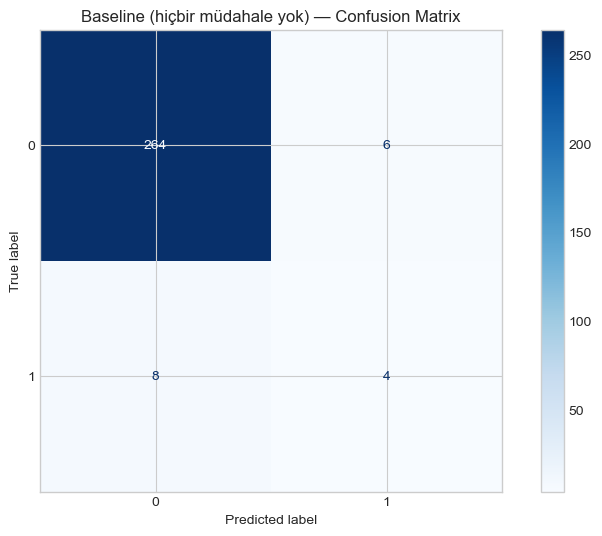

Baseline (hiçbir müdahale yok) sonuçları: {'precision': 0.4, 'recall': 0.3333, 'f1': 0.3636, 'gmean': np.float64(0.5709), 'pr_auc': 0.1617}


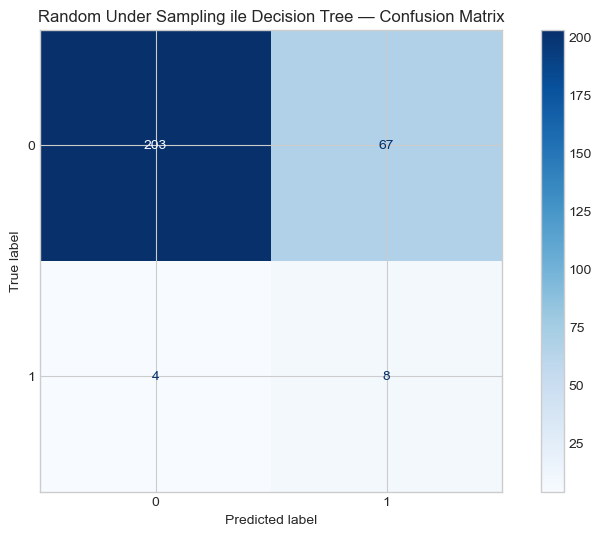

Random Under Sampling sonuçları: {'precision': 0.1067, 'recall': 0.6667, 'f1': 0.1839, 'gmean': np.float64(0.708), 'pr_auc': 0.0853}


In [142]:
print("\n==== Egzersiz 1: Random Under Sampling ile DT Confusion Matrix ====")

# Undersamplingsiz haline baseline model
clf_dt = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_oil_tr, y_oil_tr)
y_pred_oil_base = clf_dt.predict(X_oil_te)
under_results = {}
under_results["Baseline (hiçbir müdahale yok)"] = dict(
    n_egitim_sonrasi=len(y_oil_tr),
    precision=precision_score(y_oil_te, y_pred_oil_base, zero_division=0),
    recall=recall_score(y_oil_te, y_pred_oil_base),
    f1=f1_score(y_oil_te, y_pred_oil_base, zero_division=0),
    gmean=gmean_score(y_oil_te, y_pred_oil_base),
    pr_auc=average_precision_score(y_oil_te, clf_dt.predict_proba(X_oil_te)[:, 1]),
)
cm_base = confusion_matrix(y_oil_te, y_pred_oil_base)

# Undersampling ile Decision Tree
rus_sampler = RandomUnderSampler(random_state=RANDOM_STATE)
X_oil_rus, y_oil_rus = rus_sampler.fit_resample(X_oil_tr, y_oil_tr)
clf_dt_rus = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_oil_rus, y_oil_rus)
y_pred_oil_rus = clf_dt_rus.predict(X_oil_te)
under_results["Random Under Sampling"] = dict(
    n_egitim_sonrasi=len(y_oil_rus),
    precision=precision_score(y_oil_te, y_pred_oil_rus, zero_division=0),
    recall=recall_score(y_oil_te, y_pred_oil_rus),
    f1=f1_score(y_oil_te, y_pred_oil_rus, zero_division=0),
    gmean=gmean_score(y_oil_te, y_pred_oil_rus),
    pr_auc=average_precision_score(y_oil_te, clf_dt_rus.predict_proba(X_oil_te)[:, 1]),
)
cm_rus = confusion_matrix(y_oil_te, y_pred_oil_rus)

ConfusionMatrixDisplay(cm_base, display_labels=[0, 1]).plot(cmap="Blues")
plt.title("Baseline (hiçbir müdahale yok) — Confusion Matrix")
plt.show()
print("Baseline (hiçbir müdahale yok) sonuçları:", {k: round(v, 4) for k, v in under_results["Baseline (hiçbir müdahale yok)"].items() if k != "n_egitim_sonrasi"})


ConfusionMatrixDisplay(cm_rus, display_labels=[0, 1]).plot(cmap="Blues")
plt.title("Random Under Sampling ile Decision Tree — Confusion Matrix")
plt.show()
print("Random Under Sampling sonuçları:", {k: round(v, 4) for k, v in under_results["Random Under Sampling"].items() if k != "n_egitim_sonrasi"})


**E2.** 2 boyutlu, kasıtlı örtüşen, dengesiz bir `make_classification` veri seti üretin ve
$k=1$ komşulu **basit bir SMOTE'u sıfırdan** (NumPy ile, `imbalanced-learn` kullanmadan) yazın.
Ürettiğiniz sentetik noktaları orijinal azınlık noktalarıyla birlikte çizin.



==== Egzersiz 2: Sentetik Dengesiz Veri ile SMOTE Mekanizması ====
Orijinal dengesiz veri:
X: (2000, 2), y: (2000,)
Sinif dagilimi: [1952   48]


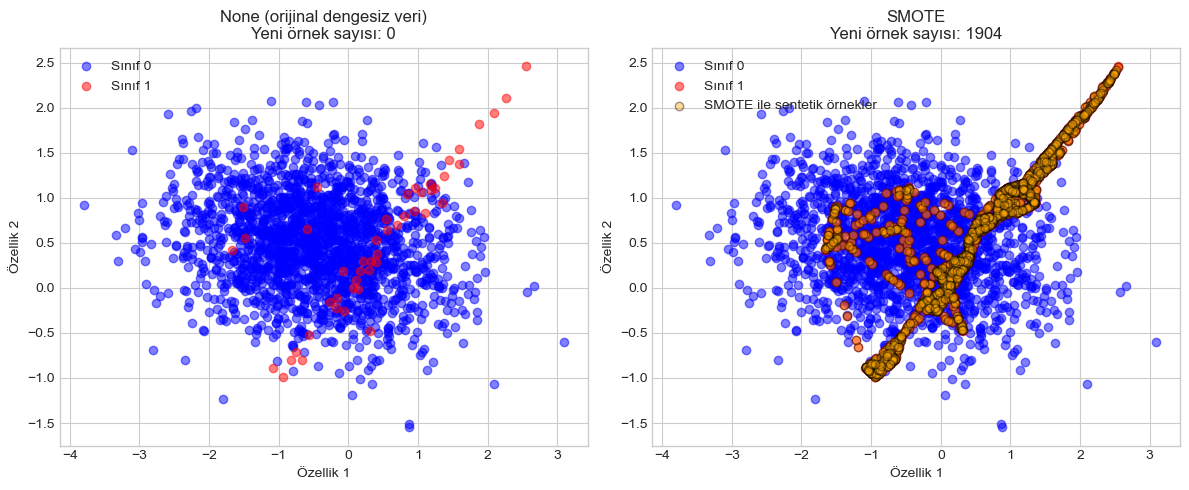

In [152]:
print("\n==== Egzersiz 2: Sentetik Dengesiz Veri ile SMOTE Mekanizması ====")

X_data, y_data = make_classification(
    n_samples=2000, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1,
    weights=[0.98, 0.02], class_sep=0.50, random_state=RANDOM_STATE
)

print("Orijinal dengesiz veri:")
print(f"X: {X_data.shape}, y: {y_data.shape}")
print(f"Sinif dagilimi: {np.bincount(y_data)}")

samplers = {
    ("None (orijinal dengesiz veri)", None),
    ("SMOTE", SMOTE(random_state=RANDOM_STATE))
}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, sampler) in zip(axes, samplers):
    if sampler is  None:
        X_res, y_res = X_data, y_data
        n_new_samples = 0
    else:
        X_res, y_res = sampler.fit_resample(X_data, y_data)
        n_new_samples = len(y_res) - len(y_data)
    ax.scatter(X_res[y_res == 0][:, 0], X_res[y_res == 0][:, 1], label="Sınıf 0", alpha=0.5, color="blue")
    ax.scatter(X_res[y_res == 1][:, 0], X_res[y_res == 1][:, 1], label="Sınıf 1", alpha=0.5, color="red")
    if n_new_samples > 0:
        ax.scatter(X_res[y_res == 1][-n_new_samples:, 0], X_res[y_res == 1][-n_new_samples:, 1],
                   label="SMOTE ile sentetik örnekler", color="orange", edgecolor="black", alpha=0.4)
    ax.set_title(f"{title}\nYeni örnek sayısı: {n_new_samples}")
    ax.set_xlabel("Özellik 1")
    ax.set_ylabel("Özellik 2")
    ax.legend()
plt.tight_layout()
plt.show()

**E3.** Mammography üzerinde `SMOTE`'un `k_neighbors` parametresini (`{1, 3, 5, 7, 9}`) bir
`StratifiedKFold` çapraz doğrulamasıyla (imblearn `Pipeline` içinde, veri sızıntısına DİKKAT
ederek) tarayıp, PR-AUC'yi maksimize eden değeri bulun.


In [ ]:
print("\n==== Egzersiz 3: Stratified K-Fold CV ile SMOTE Pipeline ====")

pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

k_neighbors = [1, 3, 5, 7, 9]

# Stratified K-Fold CV ile farklı k_neighbors SMOTE'lanmış Average Precision değerlerini test etme
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pr_auc_scores = []
for k in k_neighbors:
    pipeline.set_params(smote__k_neighbors=k)
    scores = cross_val_score(pipeline, X_oil, y_oil, cv=cv, scoring="average_precision")
    pr_auc_scores.append(scores.mean())
    print(f"k={k}: CV PR-AUC ortalaması = {scores.mean():.4f} ± {scores.std():.4f}")
print(f"En iyi k: {k_neighbors[np.argmax(pr_auc_scores)]} (PR-AUC={max(pr_auc_scores):.4f})")



==== Egzersiz 3: Stratified K-Fold CV ile SMOTE Pipeline ====
k=1: CV PR-AUC ortalaması = 0.5441 ± 0.1138
k=3: CV PR-AUC ortalaması = 0.5308 ± 0.1623
k=5: CV PR-AUC ortalaması = 0.5528 ± 0.1591
k=7: CV PR-AUC ortalaması = 0.5356 ± 0.1729
k=9: CV PR-AUC ortalaması = 0.5342 ± 0.1360
En iyi k: 5 (PR-AUC=0.5528)


**E4.** Credit Card Fraud'da `class_weight='balanced'` ile elle verilmiş birkaç farklı sözlük
(`{0:1, 1:10}`, `{0:1, 1:100}`, `{0:1, 1:578}`) arasında precision/recall/F2 nasıl değişiyor?
Sonuçları bir çizgi grafikle (x ekseni: azınlık ağırlığı, y ekseni: metrikler) gösterin.



==== Egzersiz 4: Class Weight'e Göre Logistic Regression ====
Hiç ağırlık yok: Precision=0.8636, Recall=0.6419, F2=0.6766
balanced: Precision=0.0578, Recall=0.8716, F2=0.2284
1'e 10: Precision=0.6860, Recall=0.7973, F2=0.7723
1'e 100: Precision=0.2023, Recall=0.8378, F2=0.5145
1'e 578: Precision=0.0558, Recall=0.8784, F2=0.2225


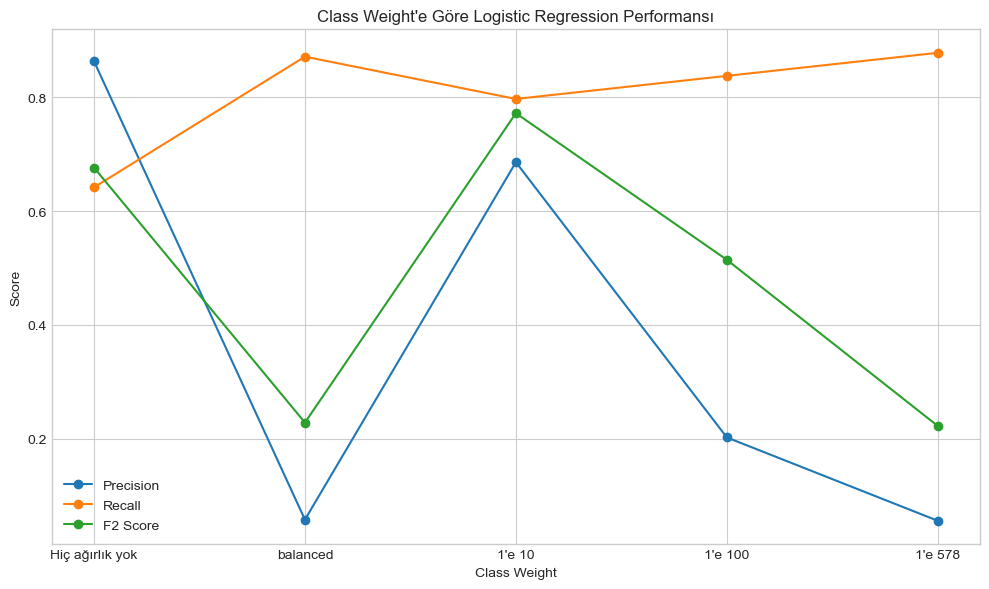

In [164]:
print("\n==== Egzersiz 4: Class Weight'e Göre Logistic Regression ====")

class_weights = {
    "Hiç ağırlık yok": None,
    "balanced": "balanced",
    "1'e 10": {0: 1, 1: 10},
    "1'e 100": {0: 1, 1: 100},
    "1'e 578": {0: 1, 1: 578},
}

precision_scores, recall_scores, f2_scores = [], [], []
for label, weight in class_weights.items():
    clf = LogisticRegression(max_iter=1000, class_weight=weight, random_state=RANDOM_STATE)
    clf.fit(X_cc_tr, y_cc_tr)
    y_pred = clf.predict(X_cc_te)
    precision = precision_score(y_cc_te, y_pred, zero_division=0)
    recall = recall_score(y_cc_te, y_pred)
    f2_score = fbeta_score(y_cc_te, y_pred, beta=2, zero_division=0)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f2_scores.append(f2_score)
    print(f"{label}: Precision={precision:.4f}, Recall={recall:.4f}, F2={f2_score:.4f}")
fig, axes = plt.subplots(figsize=(10, 6))
x = np.arange(len(class_weights))
plt.plot(x, precision_scores, marker='o', label='Precision')
plt.plot(x, recall_scores, marker='o', label='Recall')
plt.plot(x, f2_scores, marker='o', label='F2 Score')
plt.xticks(x, list(class_weights.keys()))
plt.xlabel('Class Weight')
plt.ylabel('Score')
plt.title('Class Weight\'e Göre Logistic Regression Performansı')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**E5.** Adım 11'deki veri sızıntısı deneyini Credit Card Fraud üzerinde (Oil Spill yerine)
tekrarlayın — hesaplama süresini makul tutmak için `X_cc_tr`'den dengeli küçük bir alt örneklem
alabilirsiniz, ama SIZINTI ölçümü için tüm veriye SMOTE uygulayıp sonra CV yapmayı ihmal etmeyin.
Şişme miktarı Oil Spill'dekiyle kıyaslandığında nasıl farklılaşıyor? Neden?



==== Egzersiz 5: Veri Sızıntısı ile Cross-Validation ====
YANLIŞ (sızıntılı) CV F1  : 0.9756 ± 0.0015  [0.976 0.976 0.978 0.973 0.975]
DOĞRU (pipeline içi) CV F1  : 0.8752 ± 0.0151  [0.877 0.897 0.85  0.874 0.878]
Hiç resample yok CV F1  : 0.9019 ± 0.0223  [0.909 0.937 0.872 0.907 0.884]


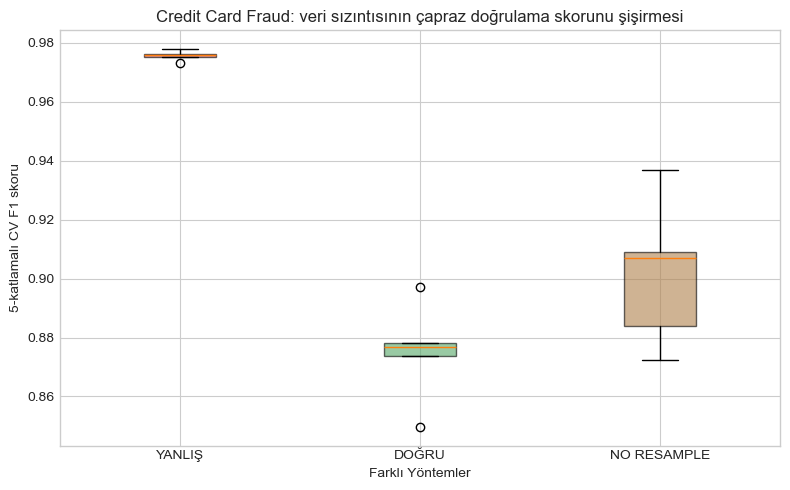

In [170]:
print("\n==== Egzersiz 5: Veri Sızıntısı ile Cross-Validation ====")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Alt örneklem alalım (hızlı çalışması için)
X_cc, y_cc = cc_sample.drop(columns=["Class"]), cc_sample["Class"]

# SMOTE Tüm Veriye Uygula ve Sonra CV (YANLIŞ)
smote_leak_cc = SMOTE(random_state=RANDOM_STATE)
X_cc_smote_all, y_cc_smote_all = smote_leak_cc.fit_resample(X_cc, y_cc)

wrong_scores_cc = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_cc_smote_all, y_cc_smote_all, cv=cv, scoring="f1"
)

# Doğru Yöntem: SMOTE Pipeline İçinde CV
correct_pipeline_cc = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
correct_scores_cc = cross_val_score(correct_pipeline_cc, X_cc, y_cc, cv=cv, scoring="f1")

# Hiçbir yeniden örnekleme yapmadan CV
no_resample_scores_cc = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_cc, y_cc, cv=cv, scoring="f1"
)
for method, scores in zip(
    ["YANLIŞ (sızıntılı)", "DOĞRU (pipeline içi)", "Hiç resample yok"],
    [wrong_scores_cc, correct_scores_cc, no_resample_scores_cc]
):
    print(f"{method} CV F1  : {scores.mean():.4f} ± {scores.std():.4f}  {np.round(scores, 3)}")


fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot_cc = [wrong_scores_cc, correct_scores_cc, no_resample_scores_cc]
labels_to_plot_cc = ["YANLIŞ", "DOĞRU", "NO RESAMPLE"]
bp_cc = ax.boxplot(data_to_plot_cc, tick_labels=labels_to_plot_cc, patch_artist=True)
for patch, color in zip(bp_cc["boxes"], ["#C44E52", "#55A868","#B0814C"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("5-katlamalı CV F1 skoru")
ax.set_xlabel("Farklı Yöntemler")
ax.set_title("Credit Card Fraud: veri sızıntısının çapraz doğrulama skorunu şişirmesi")
plt.tight_layout()
plt.show()

**E6.** `BalancedBaggingClassifier`'ı (`imblearn.ensemble`) Mammography üzerinde
`n_estimators` değerlerini (`{10, 50, 100, 200}`) tarayarak eğitin, her biri için G-mean ve eğitim
süresini kaydedip bir ödünleşim (trade-off) grafiği çizin — ne noktadan sonra ek ağaç eklemek
G-mean'i neredeyse hiç artırmıyor?



==== Egzersiz 6: Balanced Bagging ile G-mean ve Eğitim Süresi Karşılaştırması ====
Balanced Bagging sonuçları:
Balanced Bagging (10 ağaç): G-mean=0.9128, Eğitim Süresi=0.58 sn
Balanced Bagging (50 ağaç): G-mean=0.9247, Eğitim Süresi=1.21 sn
Balanced Bagging (100 ağaç): G-mean=0.9248, Eğitim Süresi=1.53 sn
Balanced Bagging (200 ağaç): G-mean=0.9252, Eğitim Süresi=2.59 sn


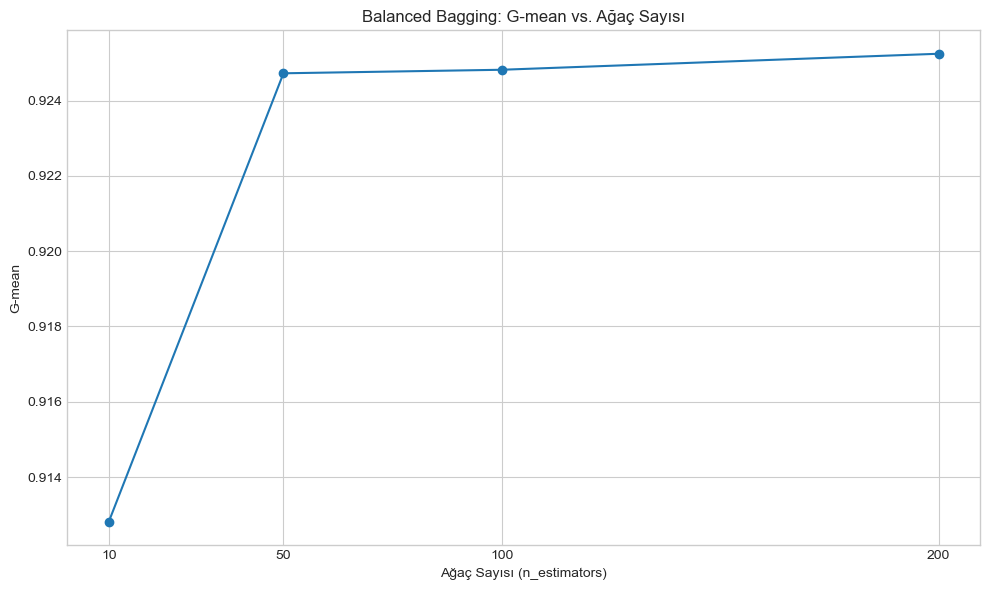

In [173]:
print("\n==== Egzersiz 6: Balanced Bagging ile G-mean ve Eğitim Süresi Karşılaştırması ====")
from imblearn.ensemble import BalancedBaggingClassifier

n_estimators_list = [10, 50, 100, 200]

blncd_bagging_results = {}
for n_estimators in n_estimators_list:
    t0 = time.time()
    clf_bagging = BalancedBaggingClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ).fit(X_cc_tr, y_cc_tr)
    y_pred_bagging = clf_bagging.predict(X_cc_te)
    blncd_bagging_results[f"Balanced Bagging ({n_estimators} ağaç)"] = dict(
        gmean=gmean_score(y_cc_te, y_pred_bagging),
        egitim_suresi_sn=time.time() - t0,
    )
print("Balanced Bagging sonuçları:")
for key, metrics in blncd_bagging_results.items():
    print(f"{key}: G-mean={metrics['gmean']:.4f}, Eğitim Süresi={metrics['egitim_suresi_sn']:.2f} sn")
plt.figure(figsize=(10, 6))
gmean_values = [metrics['gmean'] for metrics in blncd_bagging_results.values()]
plt.plot(n_estimators_list, gmean_values, marker='o')
plt.title("Balanced Bagging: G-mean vs. Ağaç Sayısı")
plt.xlabel("Ağaç Sayısı (n_estimators)")
plt.ylabel("G-mean")
plt.grid(True)
plt.xticks(n_estimators_list)
plt.tight_layout()
plt.show()

# Sınıflandırma Modellerinde Geometrik Ortalama (G-Mean)

**Geometrik Ortalama (G-Mean)**, makine öğrenmesi sınıflandırma modellerinde sensitivity (duyarlılık/recall) ve specificity (özgüllük) değerlerinin dengesini ölçen bir performans metriğidir. Özellikle veri setindeki sınıfların dengesiz dağıldığı durumlarda (imbalanced datasets), modelin hem pozitif hem de negatif sınıfı ne kadar başarılı tahmin ettiğini eş zamanlı olarak değerlendirmek amacıyla kullanılır.

## Matematiksel Formülü

G-Mean, duyarlılık (True Positive Rate) ve özgüllük (True Negative Rate) değerlerinin çarpımının karekökü alınarak hesaplanır:

$$G\text{-Mean} = \sqrt{\text{Sensitivity} \times \text{Specificity}}$$

Burada bileşenler şu şekilde tanımlanır:
*   **Sensitivity (Duyarlılık / Recall):** $\frac{\text{TP}}{\text{TP} + \text{FN}}$
*   **Specificity (Özgüllük):** $\frac{\text{TN}}{\text{TN} + \text{FP}}$

## Önemi ve Kullanım Alanları

Standart doğruluk (*accuracy*) metriği, çoğunluk sınıfının (majority class) ağırlıkta olduğu dengesiz veri setlerinde yanıltıcı sonuçlar verebilmektedir. G-Mean metriğinin temel avantajları şunlardır:

*   **Denge Kontrolü:** Model sadece tek bir sınıfa yönelip diğer sınıfı göz ardı ederse, metriklerden biri sıfıra yaklaşacağı için G-Mean değeri de hızla düşer. Yüksek bir G-Mean skoru, modelin her iki sınıfta da **dengeli bir başarı** yakaladığını gösterir.
*   **Aşırı Uyum (Overfitting) Engelleme:** Nadir görülen sınıfların (örneğin sahtekarlık tespiti veya nadir hastalık teşhisleri) gözden kaçırılmamasını sağlar.

---


## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Chawla et al. (2002) — "SMOTE: Synthetic Minority Over-sampling Technique", JAIR](https://www.jair.org/index.php/jair/article/view/10302) | SMOTE ailesi | Orijinal SMOTE makalesi, 40.000+ atıf |
| [He et al. (2008) — "ADASYN"](https://ieeexplore.ieee.org/document/4633969) | SMOTE ailesi | Adaptif sentetik örnekleme |
| [Han, Wang & Mao (2005) — "Borderline-SMOTE"](https://link.springer.com/chapter/10.1007/11538059_91) | SMOTE ailesi | Sınır-bölgesi odaklı SMOTE |
| [Batista, Prati & Monard (2004) — "A Study of the Behavior of Several Methods for Balancing Machine Learning Training Data", SIGKDD Explorations](https://dl.acm.org/doi/10.1145/1007730.1007735) | Hibrit yöntemler | SMOTEENN/SMOTETomek karşılaştırması |
| [Chen, Liaw & Breiman (2004) — "Using Random Forest to Learn Imbalanced Data"](https://statistics.berkeley.edu/sites/default/files/tech-reports/666.pdf) | Balanced Random Forest | UC Berkeley teknik raporu |
| [Liu, Wu & Zhou (2009) — "Exploratory Undersampling for Class-Imbalance Learning" (EasyEnsemble/BalanceCascade), IEEE TSMC-B](https://ieeexplore.ieee.org/document/4717268) | Ensemble | EasyEnsemble/BalanceCascade orijinal makale |
| [Seiffert et al. (2010) — "RUSBoost: A Hybrid Approach to Alleviating Class Imbalance"](https://ieeexplore.ieee.org/document/5299216) | Ensemble | RUSBoost orijinal makale |
| [Kubat, Holte & Matwin (1998) — "Machine Learning for the Detection of Oil Spills in Satellite Radar Images", Machine Learning 30](https://link.springer.com/article/10.1023/A:1007452223027) | Oil Spill veri seti | Veri setinin orijinal kaynağı |
| [Woods et al. (1993) — "Comparative Evaluation of Pattern Recognition Techniques for Detection of Microcalcifications in Mammography"](https://www.worldscientific.com/doi/abs/10.1142/S0218001493000698) | Mammography veri seti | Veri setinin orijinal kaynağı |
| [Dal Pozzolo et al. (2015) — "Calibrating Probability with Undersampling for Unbalanced Classification", IEEE SSCI](https://ieeexplore.ieee.org/document/7376606) | Credit Card Fraud veri seti | Veri setini yaratan araştırma grubu (ULB Machine Learning Group) |
| [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) | Credit Card Fraud veri seti | Orijinal Kaggle sayfası (lisans/etik notlar dahil) |
| [imbalanced-learn — Resmi Dokümantasyon](https://imbalanced-learn.org/stable/) | Tüm Python bölümü | Kullandığımız her sınıfın (SMOTE, TomekLinks, BalancedRandomForestClassifier, ...) referans dokümantasyonu |
| [imbalanced-learn — "Common pitfalls and recommended practices"](https://imbalanced-learn.org/stable/common_pitfalls.html) | Adım 11 (veri sızıntısı) | Bu notebook'un en kritik dersinin resmi kaynağı |
| [scikit-learn — "Tips on Practical Use" / `class_weight`](https://scikit-learn.org/stable/modules/svm.html#unbalanced-problems) | Sınıf ağırlıklandırma | class_weight mantığının resmi açıklaması |
| [XGBoost — "Notes on Parameter Tuning" (`scale_pos_weight`)](https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html#handle-imbalanced-dataset) | Sınıf ağırlıklandırma | scale_pos_weight resmi rehberi |
| [ROSE — CRAN paket dokümantasyonu](https://cran.r-project.org/package=ROSE) | R Uygulaması | Random/sentetik over-under sampling |
| [smotefamily — CRAN paket dokümantasyonu](https://cran.r-project.org/package=smotefamily) | R Uygulaması | SMOTE/ADASYN R karşılığı |
| [unbalanced — CRAN paket dokümantasyonu](https://cran.r-project.org/package=unbalanced) | R Uygulaması | Tomek/ENN/NCL/SMOTE (Dal Pozzolo ve ekibi tarafından yazıldı) |
| [ebmc — CRAN paket dokümantasyonu](https://cran.r-project.org/package=ebmc) | R Uygulaması | RUSBoost/SMOTEBoost R karşılığı |
| [caret — "Subsampling for Class Imbalances"](https://topepo.github.io/caret/subsampling-for-class-imbalances.html) | R Uygulaması (Adım 11 karşılığı) | trainControl(sampling=...) ile CV-içi doğru örnekleme |
| [DuckDB — Resmi Dokümantasyon](https://duckdb.org/docs/) | SQL Uygulaması | Kullanılan agregasyon/CROSS JOIN sözdizimi |
